In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_station_rows_nonna.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_station_rows_nonna.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

          STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0        USW00093193   36.7800  -119.7194  1941-12-04 00:00:00         SAO   
1        USW00093193   36.7800  -119.7194  1941-12-04 01:00:00         SAO   
2        USW00093193   36.7800  -119.7194  1941-12-04 02:00:00         SAO   
3        USW00093193   36.7800  -119.7194  1941-12-04 03:00:00         SAO   
4        USW00093193   36.7800  -119.7194  1941-12-04 04:00:00         SAO   
...              ...       ...        ...                  ...         ...   
8221089  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
8221090  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
8221091  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
8221092  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
8221093  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

         HourlyDewPointTemperature  HourlyDryBulbTemperature  \

In [3]:
# determine the number of rows that have HourlyVisibility values > 16 to check
CV_rows_hv16 = CV_rows[CV_rows['HourlyVisibility'] > 16]

print(f"Number of rows with HourlyVisibility > 16: {len(CV_rows_hv16)}")

Number of rows with HourlyVisibility > 16: 0


In [4]:
# filtering visibility threshold to get rid of nan values
CV_filtered_rows = CV_rows[CV_rows["HourlyVisibility"] < 17]

# print to see the difference
print("CV_rows:", CV_rows.shape)
print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_rows: (8221094, 18)
CV_filtered_rows: (8221094, 18)


In [5]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_filtered_rows = CV_filtered_rows[~CV_filtered_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

# print to see length after removing April-October
print("CV_filtered_rows after removing April-October:", CV_filtered_rows.shape)
print("CV_rows after removing April-October:", CV_rows.shape)

CV_filtered_rows after removing April-October: (3634348, 18)
CV_rows after removing April-October: (3634348, 18)


In [6]:
# drop duplicate station-year-month-day-hours for CV_filtered_rows
CV_filtered_rows = CV_filtered_rows.drop_duplicates(subset=['STATION', 'year', 'month', 'day', 'hour'])

# print shape
print("CV_filtered_rows after dropping duplicates:", CV_filtered_rows.shape)

CV_filtered_rows after dropping duplicates: (3035802, 18)


In [7]:
#counting days measured per year per station
filtered_days_year = (
    CV_filtered_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'filtered_days'})
    .sort_values(['STATION', 'year'])
)

print(filtered_days_year.head())
print(filtered_days_year.shape)

          STATION  year  filtered_days
0  BAKERSFIELD AP  1928             66
1  BAKERSFIELD AP  1929            120
2  BAKERSFIELD AP  1930             80
3  BAKERSFIELD AP  1931            108
4  BAKERSFIELD AP  1932            152
(998, 3)


In [8]:
# Only keep station-years with at least 150 filtered_days of data

filtered_days_filtered = filtered_days_year[filtered_days_year['filtered_days'] >= 150]

# filtered_days_filtered = filtered_days_year[filtered_days_year['filtered_days'] >= 365]


# print shape
print(filtered_days_filtered.shape)


(767, 3)


In [9]:
# only keep station-years in CV_filtered_rows listed in filtered_days_filtered
CV_filtered_rows = CV_filtered_rows.merge(filtered_days_filtered[['STATION', 'year']], on=['STATION', 'year'], how='inner')
print(CV_filtered_rows.shape)

(2696131, 18)


In [10]:
# Convert wind-from direction to wind-to direction
CV_filtered_rows['HourlyWindDirection'] = (CV_filtered_rows['HourlyWindDirection'] + 180) % 360
print(CV_filtered_rows.shape)

(2696131, 18)


In [11]:
# Define the up-valley direction for each station based on latitude
station_up_valley = (
    CV_rows[["STATION", "LATITUDE"]]
    .drop_duplicates("STATION")
    .assign(
        up_valley_direction=lambda df: np.where(
            # stations with latitude greater than or equal to 37.7 have an up-valley direction of 340 degrees
            # stations with latitude less than 37.7 have an up-valley direction of 145 degrees
            df["LATITUDE"] >= 37.7,
            340.0,
            145.0
        )
    )
)

# Add the station-specific direction to the station observations
CV_rows = CV_rows.merge(
    station_up_valley[["STATION", "up_valley_direction"]],
    on="STATION",
    how="left"
)

# Add the station-specific up-valley direction to the filtered observations
CV_filtered_rows = CV_filtered_rows.merge(
    station_up_valley[["STATION", "up_valley_direction"]],
    on="STATION",
    how="left"
)

# Check the station-specific directions
display(station_up_valley.sort_values("LATITUDE"))

,STATION,LATITUDE,up_valley_direction
2747917,BAKERSFIELD AP,35.43440,145.0
3555635,LEMOORE REEVES NAS,36.33333,145.0
0,FRESNO YOSEMITE INTL,36.78000,145.0
981239,CASTLE AFB,37.38333,145.0
712791,LIVERMORE MUNICIPAL AP,37.69270,145.0
2156243,STOCKTON AP,37.88910,340.0
1492840,TRAVIS FIELD AFB,38.26667,340.0
6090868,SACRAMENTO AP ASOS,38.50690,340.0
4057114,SACRAMENTO MATHER AFB,38.56667,340.0
4694684,SACRAMENTO MCCLELLAN AFB,38.66667,340.0


In [12]:
# Define the station-specific cross-valley direction based on latitude:
# stations below 38°N use 235°, while stations at or above 38°N use 250°.
station_up_valley["cross_valley_direction"] = np.where(
    station_up_valley["LATITUDE"] < 37.7,
    # 235.0,
    # 250.0
    55.0,
    70.0
)

# Add the cross-valley direction to the filtered observations
CV_filtered_rows = CV_filtered_rows.merge(
    station_up_valley[["STATION", "cross_valley_direction"]],
    on="STATION",
    how="left"
)

# Check the station-specific directions in the filtered observations
display(
    CV_filtered_rows[
        ["STATION", "LATITUDE", "up_valley_direction", "cross_valley_direction"]
    ].sort_values("LATITUDE")
)

,STATION,LATITUDE,up_valley_direction,cross_valley_direction
912935,BAKERSFIELD AP,35.4344,145.0,55.0
912934,BAKERSFIELD AP,35.4344,145.0,55.0
912933,BAKERSFIELD AP,35.4344,145.0,55.0
912932,BAKERSFIELD AP,35.4344,145.0,55.0
912900,BAKERSFIELD AP,35.4344,145.0,55.0
...,...,...,...,...
2696100,REDDING AP,40.5175,340.0,70.0
2696129,REDDING AP,40.5175,340.0,70.0
2696130,REDDING AP,40.5175,340.0,70.0
2696099,REDDING AP,40.5175,340.0,70.0


In [13]:
# Determine up-valley and cross-valley wind components for CV_filtered_rows
# First make sure wind direction is numeric values
wd_filtered = pd.to_numeric(CV_filtered_rows["HourlyWindDirection"], errors="coerce")

# Wind was converted to wind-toward direction previously no change is not needed

# Compute angle difference of measured wind direction relative to each station's up-valley direction
# We subtract the up-valley direction from the measured wind direction to get the relative angle
# then use deg2rad to convert the angle difference from degrees to radians
delta_along_filtered = np.deg2rad(wd_filtered - CV_filtered_rows["up_valley_direction"])

# Using the angle difference, we compute the wind components 
# Up-valley component: positive = up-valley, negative = down-valley
# multiply by the wind speed to get the actual wind component
CV_filtered_rows["up_valley_component"] = np.cos(delta_along_filtered) * CV_filtered_rows["HourlyWindSpeed"]

# Cross-valley component: positive = along cross-valley direction (defined as more eastward)
# negative = opposite cross-valley direction (defined as more westward)
delta_cross_filtered = np.deg2rad(wd_filtered - CV_filtered_rows["cross_valley_direction"])
CV_filtered_rows["cross_valley_component"] = np.cos(delta_cross_filtered) * CV_filtered_rows["HourlyWindSpeed"]

# Handle missing/calm winds
# a zero value indicates calm wind
missing_mask_filtered = wd_filtered.isna()
calm_mask_filtered = wd_filtered.eq(0)

# add missing and calm wind handling to the up-valley and cross-valley components
CV_filtered_rows.loc[missing_mask_filtered, ["up_valley_component", "cross_valley_component"]] = np.nan
CV_filtered_rows.loc[calm_mask_filtered, ["up_valley_component", "cross_valley_component"]] = 0.0

# Quick check
display(
    CV_filtered_rows[
        ["STATION", "HourlyWindDirection", "HourlyWindSpeed", "up_valley_direction",
         "cross_valley_direction", "up_valley_component", "cross_valley_component"]
    ].head(-10)
)

,STATION,HourlyWindDirection,HourlyWindSpeed,up_valley_direction,cross_valley_direction,up_valley_component,cross_valley_component
0,FRESNO YOSEMITE INTL,225.0,1.0,145.0,55.0,0.173648,-0.984808
1,FRESNO YOSEMITE INTL,225.0,0.5,145.0,55.0,0.086824,-0.492404
2,FRESNO YOSEMITE INTL,180.0,0.0,145.0,55.0,0.000000,-0.000000
3,FRESNO YOSEMITE INTL,135.0,2.1,145.0,55.0,2.068096,0.364661
4,FRESNO YOSEMITE INTL,135.0,1.5,145.0,55.0,1.477212,0.260472
...,...,...,...,...,...,...,...
2696116,REDDING AP,180.0,0.0,340.0,70.0,-0.000000,-0.000000
2696117,REDDING AP,180.0,0.0,340.0,70.0,-0.000000,-0.000000
2696118,REDDING AP,180.0,0.0,340.0,70.0,-0.000000,-0.000000
2696119,REDDING AP,320.0,2.1,340.0,70.0,1.973355,-0.718242


In [14]:
# Check calm winds
#  Display observations with calm winds, represented by wind direction = 0
calm_wind_rows = CV_filtered_rows[
    CV_filtered_rows["HourlyWindDirection"].eq(0)
]

display(calm_wind_rows)

,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,...,year,month,day,hour,minute,STATION,up_valley_direction,cross_valley_direction,up_valley_component,cross_valley_component
19,USW00093193,36.7800,-119.7194,1942-01-01 19:00:00,SAO,0.2,1.3,0.0,16.000,0.0,...,1942,1,1,19,0,FRESNO YOSEMITE INTL,145.0,55.0,0.0,0.0
22,USW00093193,36.7800,-119.7194,1942-01-01 22:00:00,SAO,-0.4,0.2,0.0,16.000,0.0,...,1942,1,1,22,0,FRESNO YOSEMITE INTL,145.0,55.0,0.0,0.0
23,USW00093193,36.7800,-119.7194,1942-01-01 23:00:00,SAO,0.8,1.3,0.0,16.000,0.0,...,1942,1,1,23,0,FRESNO YOSEMITE INTL,145.0,55.0,0.0,0.0
154,USW00093193,36.7800,-119.7194,1942-01-07 10:00:00,SAO,6.3,11.9,0.0,11.200,0.0,...,1942,1,7,10,0,FRESNO YOSEMITE INTL,145.0,55.0,0.0,0.0
155,USW00093193,36.7800,-119.7194,1942-01-07 11:00:00,SAO,6.9,13.5,0.0,11.200,0.0,...,1942,1,7,11,0,FRESNO YOSEMITE INTL,145.0,55.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695946,USW00024257,40.5175,-122.2986,2025-12-24 07:00:00,FM-12,10.6,13.9,0.0,16.000,0.0,...,2025,12,24,7,0,REDDING AP,340.0,70.0,0.0,0.0
2695951,USW00024257,40.5175,-122.2986,2025-12-24 12:05:00,FM-16,10.0,13.9,0.0,16.000,0.0,...,2025,12,24,12,5,REDDING AP,340.0,70.0,0.0,0.0
2695966,USW00024257,40.5175,-122.2986,2025-12-25 03:53:00,FM-15,9.4,11.7,3.0,4.828,0.0,...,2025,12,25,3,53,REDDING AP,340.0,70.0,0.0,0.0
2695967,USW00024257,40.5175,-122.2986,2025-12-25 04:00:00,FM-12,9.4,11.7,0.0,4.800,0.0,...,2025,12,25,4,0,REDDING AP,340.0,70.0,0.0,0.0


In [15]:
# Determine annual average up-valley and cross-valley wind magnitude by station-year
# Here "magnitude" refers to the mean signed wind component along each station-specific axis.

# Use the station-specific axes if they are already defined; otherwise create them
if "station_up_valley" not in globals():
    station_up_valley = (
        CV_rows[["STATION", "LATITUDE"]]
        .drop_duplicates("STATION")
        .assign(
            up_valley_direction=lambda df: np.where(df["LATITUDE"] >= 37.7, 340.0, 145.0),
            cross_valley_direction=lambda df: np.where(df["LATITUDE"] >= 37.7, 70.0, 55.0),
        )
    )

# Aggregate the mean up-valley and cross-valley wind components by station-year
annual_avg_wind = (
    CV_filtered_rows[
        ["STATION", "year", "up_valley_component", "cross_valley_component"]
    ]
    .dropna()
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        mean_up_valley_component=("up_valley_component", "mean"),
        mean_cross_valley_component=("cross_valley_component", "mean"),
        n_obs=("up_valley_component", "size"),
    )
    .sort_values(["STATION", "year"])
    .reset_index(drop=True)
)

# Optional: attach latitude for geographic context
station_lat = (
    CV_filtered_rows.groupby("STATION", as_index=False)["LATITUDE"]
    .median()
    .rename(columns={"LATITUDE": "latitude"})
)

annual_avg_wind = annual_avg_wind.merge(station_lat, on="STATION", how="left")

print(f"Rows in annual_avg_wind: {len(annual_avg_wind)}")
display(annual_avg_wind.head(10))

Rows in annual_avg_wind: 767


,STATION,year,mean_up_valley_component,mean_cross_valley_component,n_obs,latitude
0,BAKERSFIELD AP,1932,0.263368,-0.583223,3634,35.4344
1,BAKERSFIELD AP,1933,0.416877,-0.590281,3611,35.4344
2,BAKERSFIELD AP,1934,0.646782,-0.355681,3619,35.4344
3,BAKERSFIELD AP,1935,0.619386,-0.383051,3620,35.4344
4,BAKERSFIELD AP,1936,0.504009,-0.473694,3648,35.4344
5,BAKERSFIELD AP,1937,0.367686,-0.527409,3618,35.4344
6,BAKERSFIELD AP,1938,0.131910,-0.505374,3621,35.4344
7,BAKERSFIELD AP,1939,0.293792,-0.585424,3593,35.4344
8,BAKERSFIELD AP,1946,0.662027,-0.586418,3606,35.4344
9,BAKERSFIELD AP,1947,0.576132,-0.473419,3591,35.4344


Total station-component regressions: 28
Significant trends (p < 0.05): 13


,STATION,component,start_year,end_year,n_years,slope_per_year,slope_per_decade,intercept,r_squared,p_value
0,BEALE AFB,cross_valley,1960,2025,36,-0.006370,-0.063701,12.413019,0.610463,1.871148e-08
1,LEMOORE REEVES NAS,cross_valley,1962,2025,42,0.003832,0.038316,-7.641823,0.428192,2.597045e-06
2,RED BLUFF MUNI AP,cross_valley,1946,2024,68,-0.002211,-0.022111,4.520726,0.222940,4.802050e-05
3,BAKERSFIELD AP,cross_valley,1932,2025,83,0.001400,0.014005,-3.186650,0.140552,4.794110e-04
4,SACRAMENTO METROPOLITAN AP,cross_valley,1976,2025,39,0.004469,0.044687,-8.776585,0.222049,2.462381e-03
5,SACRAMENTO AP ASOS,cross_valley,1932,2025,82,0.001623,0.016228,-3.037654,0.092980,5.344539e-03
6,SACRAMENTO MCCLELLAN AFB,cross_valley,1940,2025,58,0.002564,0.025637,-5.234310,0.117136,8.546038e-03
7,CASTLE AFB,cross_valley,1942,2022,42,0.002284,0.022843,-4.693270,0.153921,1.017596e-02
8,FRESNO YOSEMITE INTL,cross_valley,1942,2025,71,0.001426,0.014265,-3.039334,0.084288,1.404747e-02
9,SACRAMENTO MATHER AFB,cross_valley,1942,2025,56,0.001426,0.014259,-2.873428,0.071326,4.661395e-02


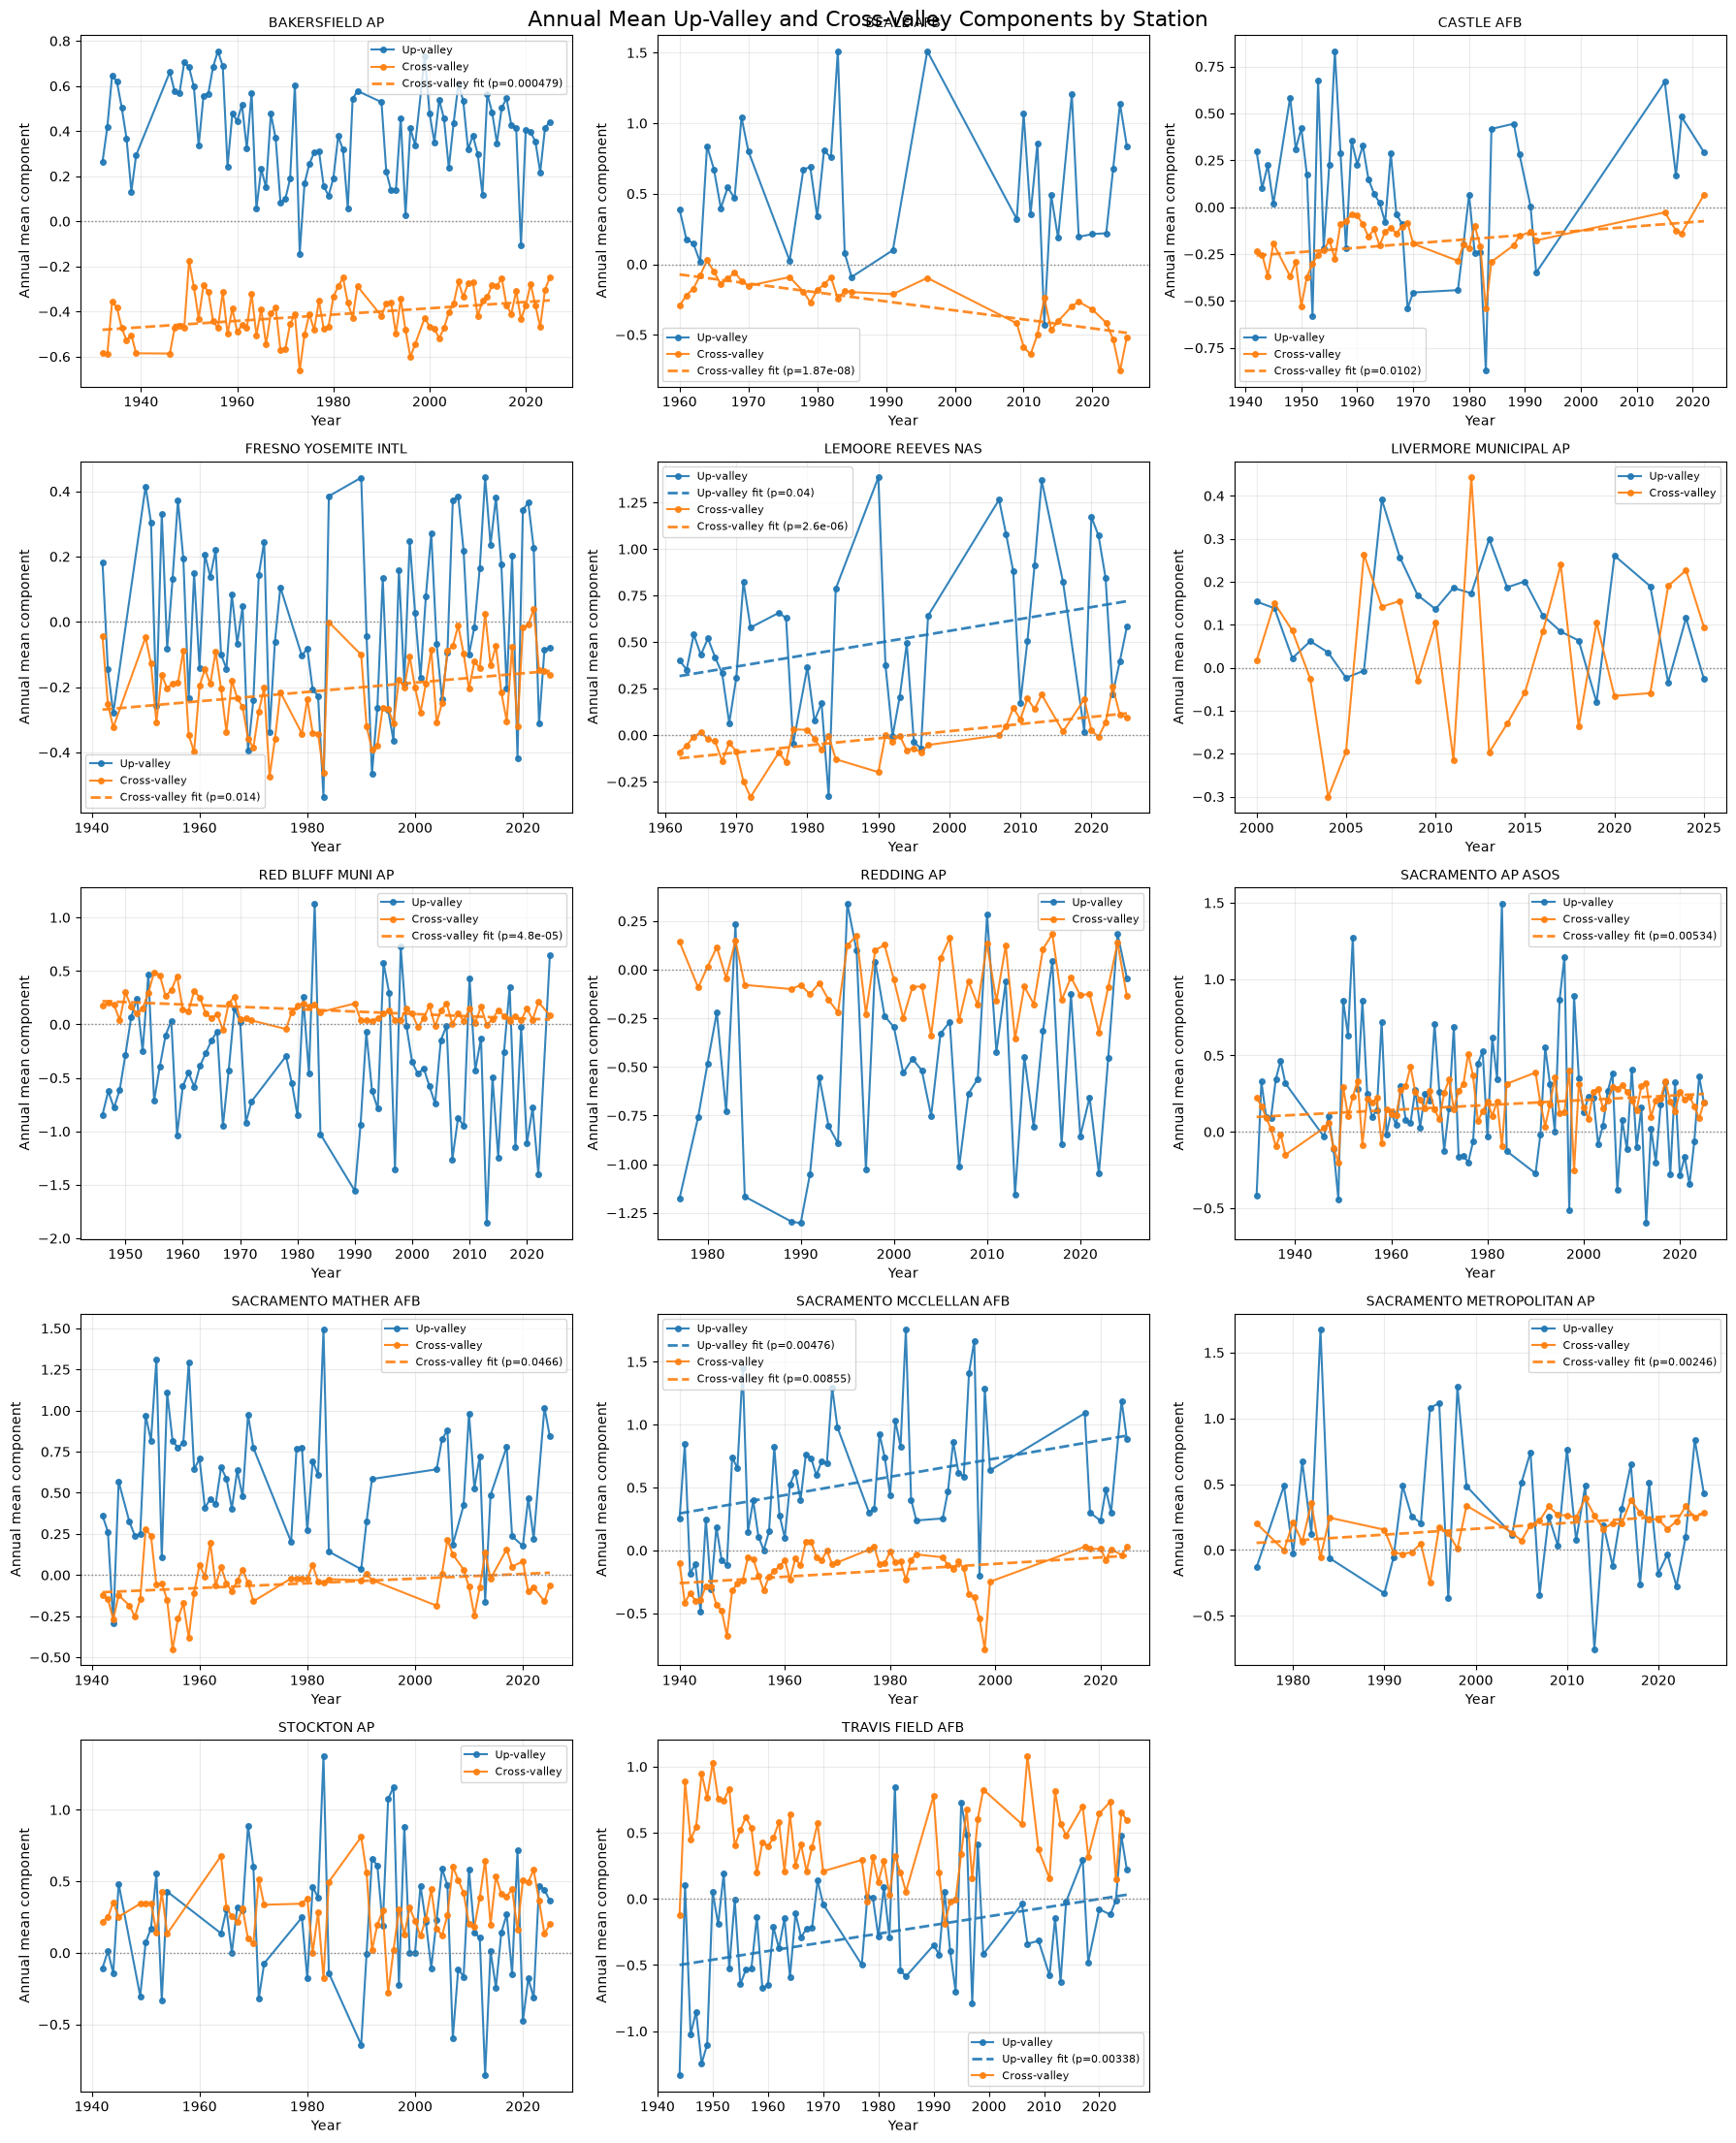

In [16]:
# Trend analysis of annual mean up-valley and cross-valley components by station
# Only plot regression lines for statistically significant trends (p < 0.05)

trend_rows = []

for station, g in annual_avg_wind.groupby("STATION"):
    for component, value_col in [
        ("up_valley", "mean_up_valley_component"),
        ("cross_valley", "mean_cross_valley_component"),
    ]:
        d = g[["year", value_col]].dropna()

        if d.empty or d["year"].nunique() < 3 or d[value_col].nunique() < 2:
            continue

        fit = stats.linregress(d["year"].to_numpy(), d[value_col].to_numpy())

        trend_rows.append({
            "STATION": station,
            "component": component,
            "start_year": int(d["year"].min()),
            "end_year": int(d["year"].max()),
            "n_years": int(d["year"].nunique()),
            "slope_per_year": fit.slope,
            "slope_per_decade": fit.slope * 10,
            "intercept": fit.intercept,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

trend_df = pd.DataFrame(trend_rows).sort_values(["STATION", "component"]).reset_index(drop=True)
sig_trends = trend_df[trend_df["p_value"] < 0.05].copy()

print(f"Total station-component regressions: {len(trend_df)}")
print(f"Significant trends (p < 0.05): {len(sig_trends)}")
display(sig_trends.sort_values(["component", "p_value"]).reset_index(drop=True))

stations = sorted(annual_avg_wind["STATION"].unique())
ncols = 3
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows), squeeze=False)
axes = axes.ravel()

for ax, station in zip(axes, stations):
    d = annual_avg_wind[annual_avg_wind["STATION"] == station].sort_values("year")

    for component, value_col, color, label in [
        ("up_valley", "mean_up_valley_component", "tab:blue", "Up-valley"),
        ("cross_valley", "mean_cross_valley_component", "tab:orange", "Cross-valley"),
    ]:
        ax.plot(
            d["year"],
            d[value_col],
            marker="o",
            markersize=4,
            linewidth=1.5,
            color=color,
            label=label,
            alpha=0.9,
        )

        result = trend_df[
            (trend_df["STATION"] == station) &
            (trend_df["component"] == component)
        ]

        if not result.empty and result.iloc[0]["p_value"] < 0.05:
            fit = result.iloc[0]
            fitted = fit["intercept"] + fit["slope_per_year"] * d["year"]
            ax.plot(
                d["year"],
                fitted,
                color=color,
                linestyle="--",
                linewidth=2,
                alpha=0.9,
                label=f"{label} fit (p={fit['p_value']:.3g})"
            )

    ax.axhline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(station, fontsize=10)
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual mean component")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc="best")

for ax in axes[len(stations):]:
    ax.remove()

fig.suptitle("Annual Mean Up-Valley and Cross-Valley Components by Station", fontsize=16)
plt.tight_layout()
plt.show()

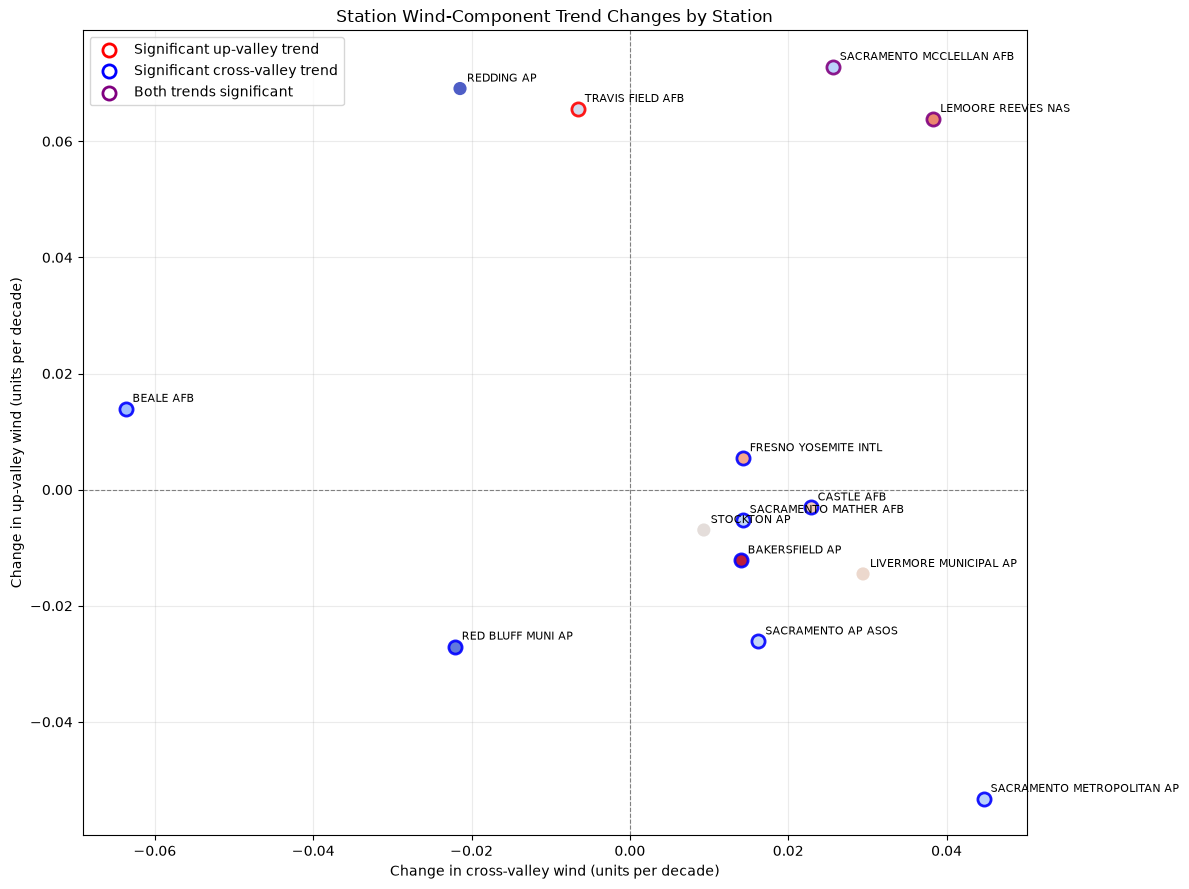

In [17]:
# Plot each station's change in up-valley wind vs. change in cross-valley wind
# Red outline = significant up-valley trend
# Blue outline = significant cross-valley trend
# Purple outline = both significant

slope_data = (
    trend_df
    .pivot(index="STATION", columns="component", values=["slope_per_decade", "p_value"])
    .dropna()
)

slope_data.columns = [
    f"{metric}_{component}"
    for metric, component in slope_data.columns
]

plot_data = (
    slope_data
    .reset_index()
    .merge(station_lat, on="STATION", how="left")
    .dropna(subset=["latitude"])
)

lat_min = plot_data["latitude"].min()
lat_max = plot_data["latitude"].max()
lat_range = lat_max - lat_min if lat_max != lat_min else 1

fig, ax = plt.subplots(figsize=(12, 9))

for _, row in plot_data.iterrows():
    station = row["STATION"]
    x = row["slope_per_decade_cross_valley"]
    y = row["slope_per_decade_up_valley"]

    sig_up = row["p_value_up_valley"] < 0.05
    sig_cross = row["p_value_cross_valley"] < 0.05

    if sig_up and sig_cross:
        outline_color = "purple"
    elif sig_up:
        outline_color = "red"
    elif sig_cross:
        outline_color = "blue"
    else:
        outline_color = "none"

    point_color = plt.cm.coolwarm_r((row["latitude"] - lat_min) / lat_range)

    ax.scatter(
        x,
        y,
        color=point_color,
        edgecolors=outline_color,
        linewidths=2 if outline_color != "none" else 0.8,
        s=90,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

for color, label in [
    ("red", "Significant up-valley trend"),
    ("blue", "Significant cross-valley trend"),
    ("purple", "Both trends significant"),
]:
    ax.scatter(
        [], [],
        color="white",
        edgecolors=color,
        linewidths=2,
        s=90,
        label=label,
    )

ax.set_xlabel("Change in cross-valley wind (units per decade)")
ax.set_ylabel("Change in up-valley wind (units per decade)")
ax.set_title("Station Wind-Component Trend Changes by Station")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

BREAK: code below needs to be redone
_________________


In [18]:
# Determine annual average up-valley and cross-valley wind direction by station-year

# Use the station-specific axes if they are already defined; otherwise create them
if "station_up_valley" not in globals():
    station_up_valley = (
        CV_rows[["STATION", "LATITUDE"]]
        .drop_duplicates("STATION")
        .assign(
            up_valley_direction=lambda df: np.where(df["LATITUDE"] >= 37.7, 340.0, 145.0),
            cross_valley_direction=lambda df: np.where(df["LATITUDE"] >= 37.7, 70.0, 55.0),
        )
    )

# Merge station axes onto the full station-year dataset
annual_wind_dir = (
    CV_filtered_rows[["STATION", "year", "HourlyWindDirection", "HourlyWindSpeed", "LATITUDE"]]
    .merge(
        station_up_valley[["STATION", "up_valley_direction", "cross_valley_direction"]],
        on="STATION",
        how="left"
    )
    .copy()
)

# # Convert wind-from direction to wind-toward direction
# we already did this for CV_filtered_rows, so we can reuse the wd and wd_to columns
wd = pd.to_numeric(annual_wind_dir["HourlyWindDirection"], errors="coerce")


# Keep only valid, non-calm observations
valid = wd.notna() & wd.ne(0)
# Filter out invalid wind observations before further analysis
annual_wind_dir = annual_wind_dir.loc[valid].copy()
# Keep only the valid wind observations for further analysis
annual_wind_dir["wd_to"] = wd.loc[valid].to_numpy()

# Compute angle differences relative to each station's local axes
# Do this by subtracting the station-specific up-valley and cross-valley directions from the wind-toward direction
# convert to radians
annual_wind_dir["up_valley_delta_rad"] = np.deg2rad(
    annual_wind_dir["wd_to"] - annual_wind_dir["up_valley_direction"]
)
annual_wind_dir["cross_valley_delta_rad"] = np.deg2rad(
    annual_wind_dir["wd_to"] - annual_wind_dir["cross_valley_direction"]
)

# Cosine/sine components on each axis
# up_valley_cos is the cosine of the angle difference between the wind direction and the up-valley direction
# multiply by the wind speed to get the actual wind component along the up-valley direction
annual_wind_dir["up_valley_cos"] = np.cos(annual_wind_dir["up_valley_delta_rad"]) * annual_wind_dir["HourlyWindSpeed"]
# up_valley_sin is the sine of the angle difference between the wind direction and the up-valley direction
annual_wind_dir["up_valley_sin"] = np.sin(annual_wind_dir["up_valley_delta_rad"]) * annual_wind_dir["HourlyWindSpeed"]
# cross_valley_cos is the cosine of the angle difference between the wind direction and the cross-valley direction
annual_wind_dir["cross_valley_cos"] = np.cos(annual_wind_dir["cross_valley_delta_rad"]) * annual_wind_dir["HourlyWindSpeed"]
# cross_valley_sin is the sine of the angle difference between the wind direction and the cross-valley direction
annual_wind_dir["cross_valley_sin"] = np.sin(annual_wind_dir["cross_valley_delta_rad"]) * annual_wind_dir["HourlyWindSpeed"]

# Get magnitude of the wind components along the up-valley and cross-valley directions
# up_valley_magnitude is the magnitude of the wind component along the up-valley direction
# we get this by multiplying the component along the up-valley direction (cosine) by the wind speed
annual_wind_dir["up_valley_magnitude"] = np.abs(annual_wind_dir["up_valley_cos"])
# cross_valley_magnitude is the magnitude of the wind component along the cross-valley direction
annual_wind_dir["cross_valley_magnitude"] = np.abs(annual_wind_dir["cross_valley_cos"])

# Aggregate to annual station means
annual_avg_wind_dir = (
    annual_wind_dir
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        n_obs=("wd_to", "size"),
        mean_up_valley_cos=("up_valley_cos", "mean"),
        mean_up_valley_sin=("up_valley_sin", "mean"),
        mean_cross_valley_cos=("cross_valley_cos", "mean"),
        mean_cross_valley_sin=("cross_valley_sin", "mean"),
    )
)

# Convert vector means back to angular direction in degrees
annual_avg_wind_dir["avg_up_valley_direction_deg"] = np.mod(
    np.rad2deg(
        np.arctan2(
            annual_avg_wind_dir["mean_up_valley_sin"],
            annual_avg_wind_dir["mean_up_valley_cos"],
        )
    ),
    360.0,
)

annual_avg_wind_dir["avg_cross_valley_direction_deg"] = np.mod(
    np.rad2deg(
        np.arctan2(
            annual_avg_wind_dir["mean_cross_valley_sin"],
            annual_avg_wind_dir["mean_cross_valley_cos"],
        )
    ),
    360.0,
)

# Keep the mean component values for convenience
annual_avg_wind_dir["mean_up_valley_component"] = annual_avg_wind_dir["mean_up_valley_cos"]
annual_avg_wind_dir["mean_cross_valley_component"] = annual_avg_wind_dir["mean_cross_valley_cos"]

annual_avg_wind_dir = annual_avg_wind_dir.sort_values(["STATION", "year"]).reset_index(drop=True)

display(annual_avg_wind_dir.head(10))

,STATION,year,n_obs,mean_up_valley_cos,mean_up_valley_sin,mean_cross_valley_cos,mean_cross_valley_sin,avg_up_valley_direction_deg,avg_cross_valley_direction_deg,mean_up_valley_component,mean_cross_valley_component
0,BAKERSFIELD AP,1932,3529,0.271204,0.600576,-0.600576,0.271204,65.697364,155.697364,0.271204,-0.600576
1,BAKERSFIELD AP,1933,3474,0.433317,0.613559,-0.613559,0.433317,54.768911,144.768911,0.433317,-0.613559
2,BAKERSFIELD AP,1934,3452,0.678072,0.372888,-0.372888,0.678072,28.807422,118.807422,0.678072,-0.372888
3,BAKERSFIELD AP,1935,3518,0.637345,0.394157,-0.394157,0.637345,31.734138,121.734138,0.637345,-0.394157
4,BAKERSFIELD AP,1936,3547,0.518360,0.487183,-0.487183,0.518360,43.224054,133.224054,0.518360,-0.487183
5,BAKERSFIELD AP,1937,3487,0.381500,0.547223,-0.547223,0.381500,55.117521,145.117521,0.381500,-0.547223
6,BAKERSFIELD AP,1938,3485,0.137058,0.525096,-0.525096,0.137058,75.371365,165.371365,0.137058,-0.525096
7,BAKERSFIELD AP,1939,3476,0.303680,0.605129,-0.605129,0.303680,63.350493,153.350493,0.303680,-0.605129
8,BAKERSFIELD AP,1946,3476,0.686786,0.608350,-0.608350,0.686786,41.534276,131.534276,0.686786,-0.608350
9,BAKERSFIELD AP,1947,3475,0.595364,0.489223,-0.489223,0.595364,39.410612,129.410612,0.595364,-0.489223


Total station-component trends tested: 28
Significant trends (p < 0.05): 13


,STATION,component,start_year,end_year,n_years,slope_per_year,slope_per_decade,intercept,r_squared,p_value
0,BEALE AFB,cross_valley,1960,2025,36,-0.006402,-0.064025,12.468924,0.594124,3.809376e-08
1,LEMOORE REEVES NAS,cross_valley,1962,2025,42,0.003917,0.039172,-7.812847,0.429424,2.484225e-06
2,RED BLUFF MUNI AP,cross_valley,1946,2024,68,-0.002426,-0.024263,4.955093,0.236319,2.637568e-05
3,BAKERSFIELD AP,cross_valley,1932,2025,83,0.001543,0.015431,-3.476022,0.159886,1.802945e-04
4,SACRAMENTO MCCLELLAN AFB,cross_valley,1940,2025,58,0.003197,0.031971,-6.501859,0.151195,2.557021e-03
5,SACRAMENTO METROPOLITAN AP,cross_valley,1976,2025,39,0.004622,0.046225,-9.076132,0.214788,2.964794e-03
6,CASTLE AFB,cross_valley,1942,2022,42,0.002493,0.024926,-5.110075,0.167571,7.103566e-03
7,FRESNO YOSEMITE INTL,cross_valley,1942,2025,71,0.001576,0.015758,-3.340827,0.097982,7.862897e-03
8,SACRAMENTO AP ASOS,cross_valley,1932,2025,82,0.001573,0.015734,-2.932650,0.079534,1.026098e-02
9,SACRAMENTO MATHER AFB,cross_valley,1942,2025,56,0.001615,0.016149,-3.251740,0.076103,3.959365e-02


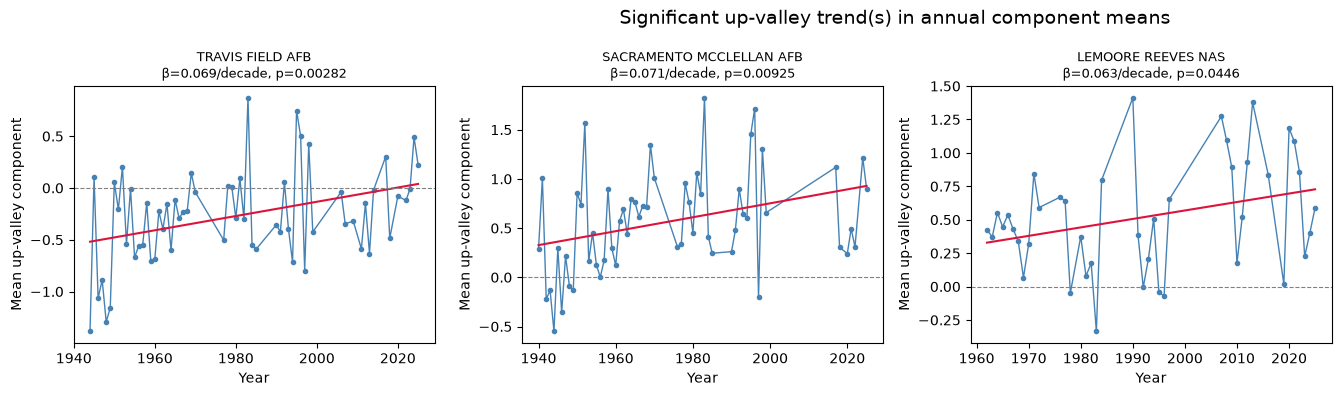

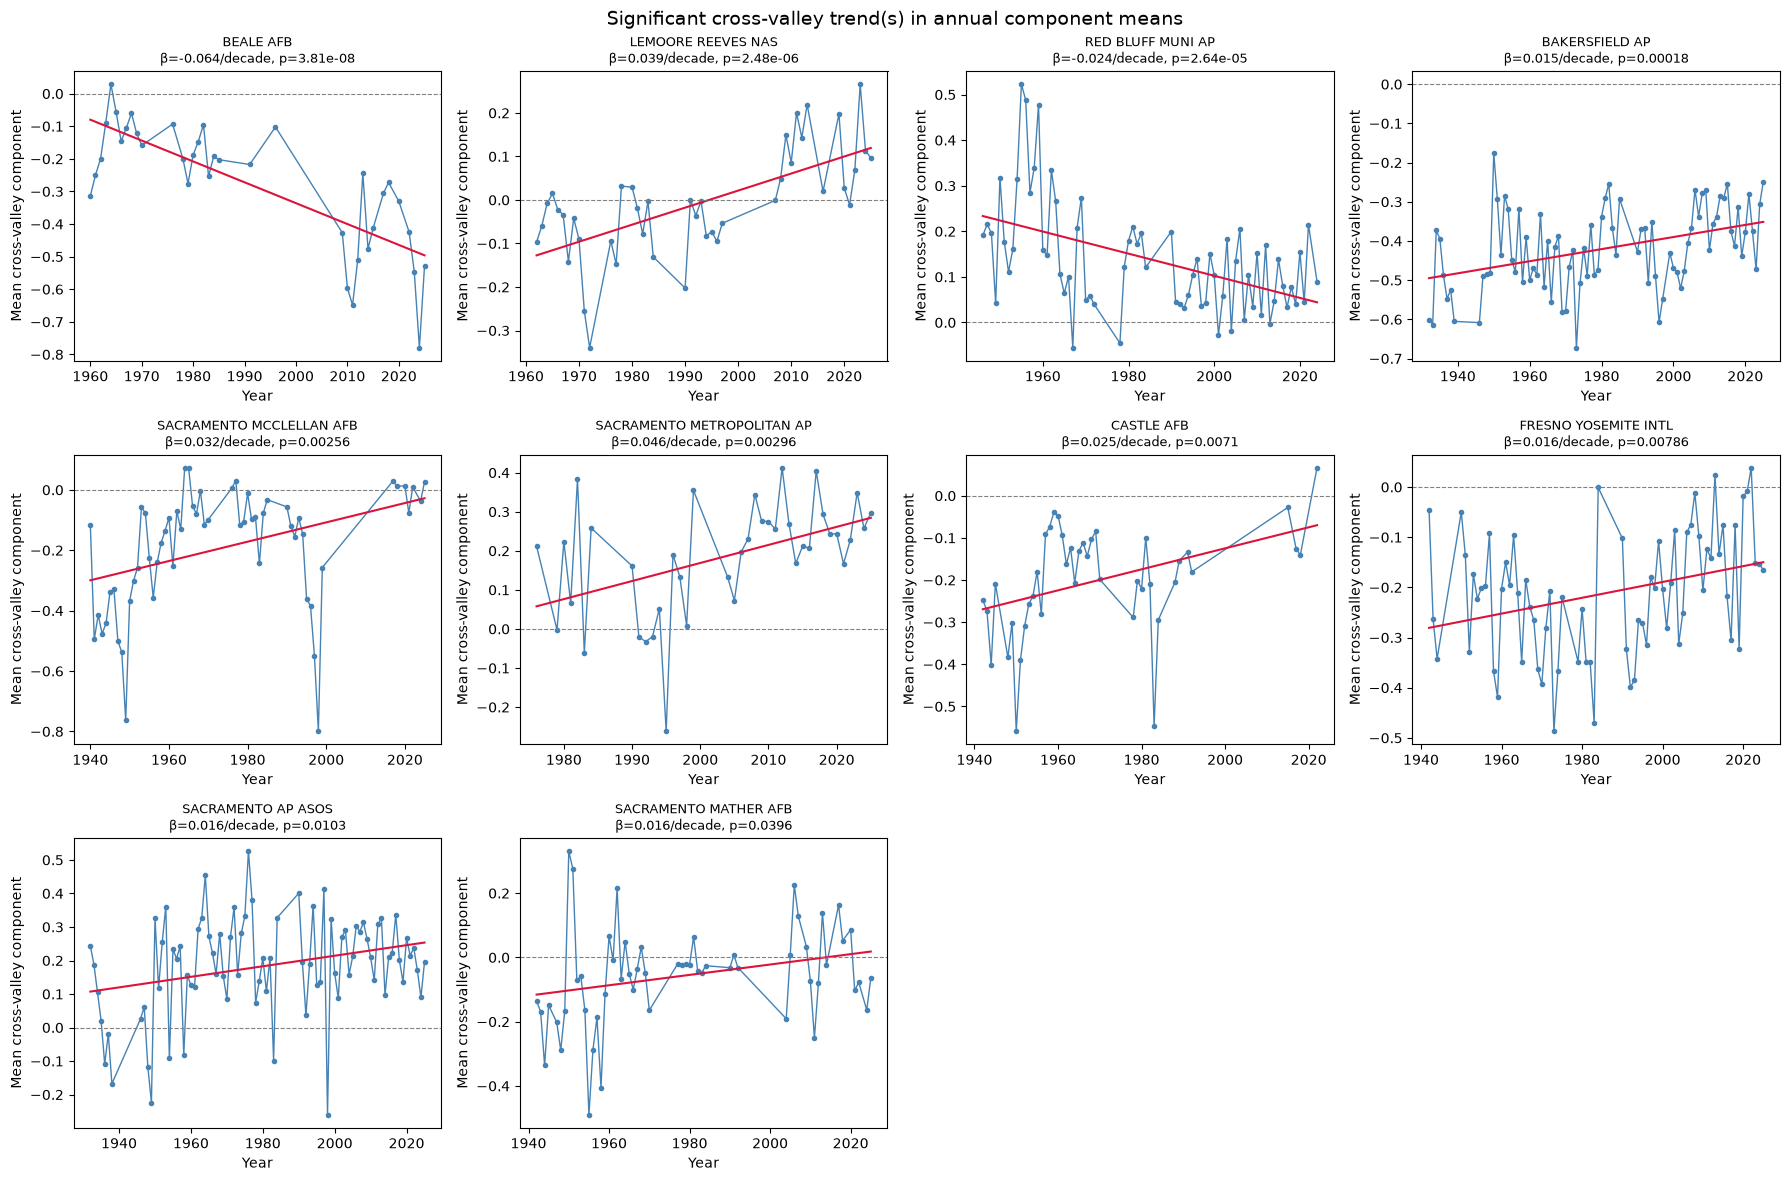

In [19]:
# Annual average up-valley and cross-valley components by station and year
# Use the existing raw station-year wind-direction table if available
if "annual_wind_dir" not in globals():
    annual_wind_dir = annual_avg_wind_dir.copy()

annual_components = (
    annual_wind_dir
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        mean_up_valley_component=("up_valley_cos", "mean"),
        mean_cross_valley_component=("cross_valley_cos", "mean"),
        n_obs=("up_valley_cos", "size"),
    )
    .sort_values(["STATION", "year"])
)

# Fit linear trends for each station/component
trend_rows = []

for station, g in annual_components.groupby("STATION"):
    for col, component in [
        ("mean_up_valley_component", "up_valley"),
        ("mean_cross_valley_component", "cross_valley"),
    ]:
        d = g[["year", col]].dropna()

        if d["year"].nunique() < 10 or d[col].nunique() < 2:
            continue

        fit = stats.linregress(d["year"].to_numpy(), d[col].to_numpy())

        trend_rows.append({
            "STATION": station,
            "component": component,
            "start_year": int(d["year"].min()),
            "end_year": int(d["year"].max()),
            "n_years": int(d["year"].nunique()),
            "slope_per_year": fit.slope,
            "slope_per_decade": fit.slope * 10,
            "intercept": fit.intercept,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

trend_df = pd.DataFrame(trend_rows)
sig_trends = trend_df[trend_df["p_value"] < 0.05].copy()

print(f"Total station-component trends tested: {len(trend_df)}")
print(f"Significant trends (p < 0.05): {len(sig_trends)}")
display(sig_trends.sort_values(["component", "p_value"]).reset_index(drop=True))

# Plot only significant trends
for comp_name, value_col, ylab in [
    ("up_valley", "mean_up_valley_component", "Mean up-valley component"),
    ("cross_valley", "mean_cross_valley_component", "Mean cross-valley component"),
]:
    sig_comp = sig_trends[sig_trends["component"] == comp_name].sort_values("p_value")

    if sig_comp.empty:
        print(f"No significant {comp_name.replace('_', '-')} trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(sig_comp) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), squeeze=False)
    axes = axes.ravel()

    for ax, (_, result) in zip(axes, sig_comp.iterrows()):
        d = annual_components[
            annual_components["STATION"] == result["STATION"]
        ][["year", value_col]].dropna().sort_values("year")

        if d.empty:
            continue

        # Use a trend line based on the fitted slope and intercept
        fitted = result["intercept"] + result["slope_per_year"] * d["year"]

        ax.plot(d["year"], d[value_col], marker="o", markersize=3, linewidth=1, color="steelblue")
        ax.plot(d["year"], fitted, color="crimson", linewidth=1.5)
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

        ax.set_title(
            f"{result['STATION']}\n"
            f"β={result['slope_per_decade']:.3f}/decade, p={result['p_value']:.3g}",
            fontsize=9,
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(ylab)

    for ax in axes[len(sig_comp):]:
        ax.remove()

    fig.suptitle(f"Significant {comp_name.replace('_', '-')} trend(s) in annual component means", fontsize=14)
    plt.tight_layout()
    plt.show()

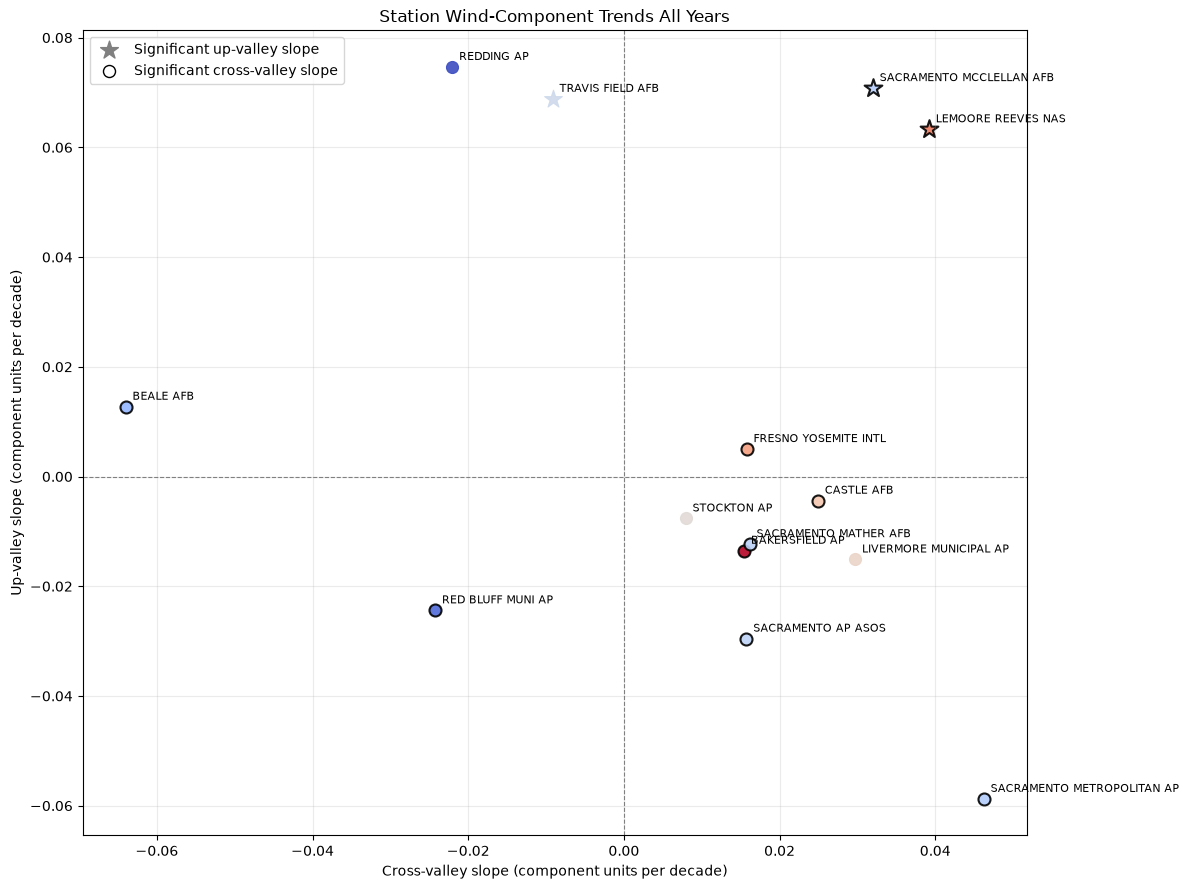

In [20]:
# Plot station trend slopes:
# x-axis = cross-valley slope, y-axis = up-valley slope.
# Significant up-valley trends use star markers.
# Significant cross-valley trends have black outlines.

slope_data = (
    trend_df
    .pivot(index="STATION", columns="component", values=["slope_per_decade", "p_value"])
    .dropna()
)

slope_data.columns = [
    f"{metric}_{component}"
    for metric, component in slope_data.columns
]

# Attach latitude for coloring
station_lat = (
    CV_filtered_rows.groupby("STATION", as_index=False)["LATITUDE"]
    .median()
    .rename(columns={"LATITUDE": "latitude"})
)
plot_data = slope_data.merge(station_lat, on="STATION", how="left").dropna(subset=["latitude"])

lat_min = plot_data["latitude"].min()
lat_max = plot_data["latitude"].max()
lat_range = lat_max - lat_min if lat_max != lat_min else 1

fig, ax = plt.subplots(figsize=(12, 9))

for _, row in plot_data.iterrows():
    station = row["STATION"]
    color = plt.cm.coolwarm_r((row["latitude"] - lat_min) / lat_range)

    significant_cross = row["p_value_cross_valley"] < 0.05
    significant_up = row["p_value_up_valley"] < 0.05

    ax.scatter(
        row["slope_per_decade_cross_valley"],
        row["slope_per_decade_up_valley"],
        color=color,
        marker="*" if significant_up else "o",
        s=180 if significant_up else 75,
        edgecolors="black" if significant_cross else color,
        linewidths=1.5 if significant_cross else 0.8,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (row["slope_per_decade_cross_valley"], row["slope_per_decade_up_valley"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

# Reference axes
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

# Legend for significance styles
ax.scatter(
    [], [], color="gray", marker="*", s=180,
    label="Significant up-valley slope"
)
ax.scatter(
    [], [], color="white", edgecolors="black", s=75,
    label="Significant cross-valley slope"
)

ax.set_xlabel("Cross-valley slope (component units per decade)")
ax.set_ylabel("Up-valley slope (component units per decade)")
ax.set_title("Station Wind-Component Trends All Years")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

,STATION,year,mean_up_valley_component,mean_cross_valley_component,n_obs
0,BAKERSFIELD AP,1980,0.191294,-0.334594,3644
1,BAKERSFIELD AP,1981,0.377436,-0.288490,3622
2,BAKERSFIELD AP,1982,0.317884,-0.250514,3621
3,BAKERSFIELD AP,1983,0.057491,-0.361042,3618
4,BAKERSFIELD AP,1984,0.542488,-0.427633,3630
...,...,...,...,...,...
443,TRAVIS FIELD AFB,2020,-0.077261,0.643798,3550
444,TRAVIS FIELD AFB,2022,-0.118689,0.736210,3490
445,TRAVIS FIELD AFB,2023,-0.010248,0.152208,3454
446,TRAVIS FIELD AFB,2024,0.477495,0.656665,3558


,STATION,component,start_year,end_year,n_years,slope_per_year,slope_per_decade,intercept,r_squared,p_value
9,LEMOORE REEVES NAS,cross_valley,1980,2025,28,0.004938,0.049383,-9.862822,0.448536,0.000097
3,BEALE AFB,cross_valley,1980,2025,22,-0.008229,-0.082291,16.150587,0.531958,0.000117
7,FRESNO YOSEMITE INTL,cross_valley,1980,2025,41,0.004890,0.048896,-9.983778,0.259023,0.000679
23,SACRAMENTO METROPOLITAN AP,cross_valley,1980,2025,37,0.004835,0.048354,-9.513947,0.225021,0.003015
27,TRAVIS FIELD AFB,cross_valley,1980,2025,30,0.010240,0.102395,-20.091833,0.229204,0.007442
5,CASTLE AFB,cross_valley,1980,2022,13,0.005452,0.054517,-11.051608,0.380847,0.024641
16,SACRAMENTO AP ASOS,up_valley,1980,2025,41,-0.012052,-0.120518,24.310830,0.133782,0.018686
8,LEMOORE REEVES NAS,up_valley,1980,2025,28,0.012018,0.120184,-23.529487,0.141241,0.048734


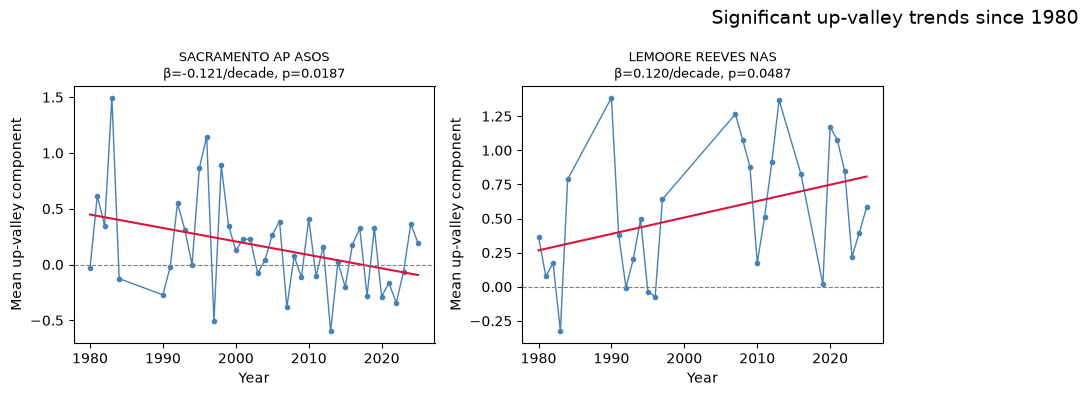

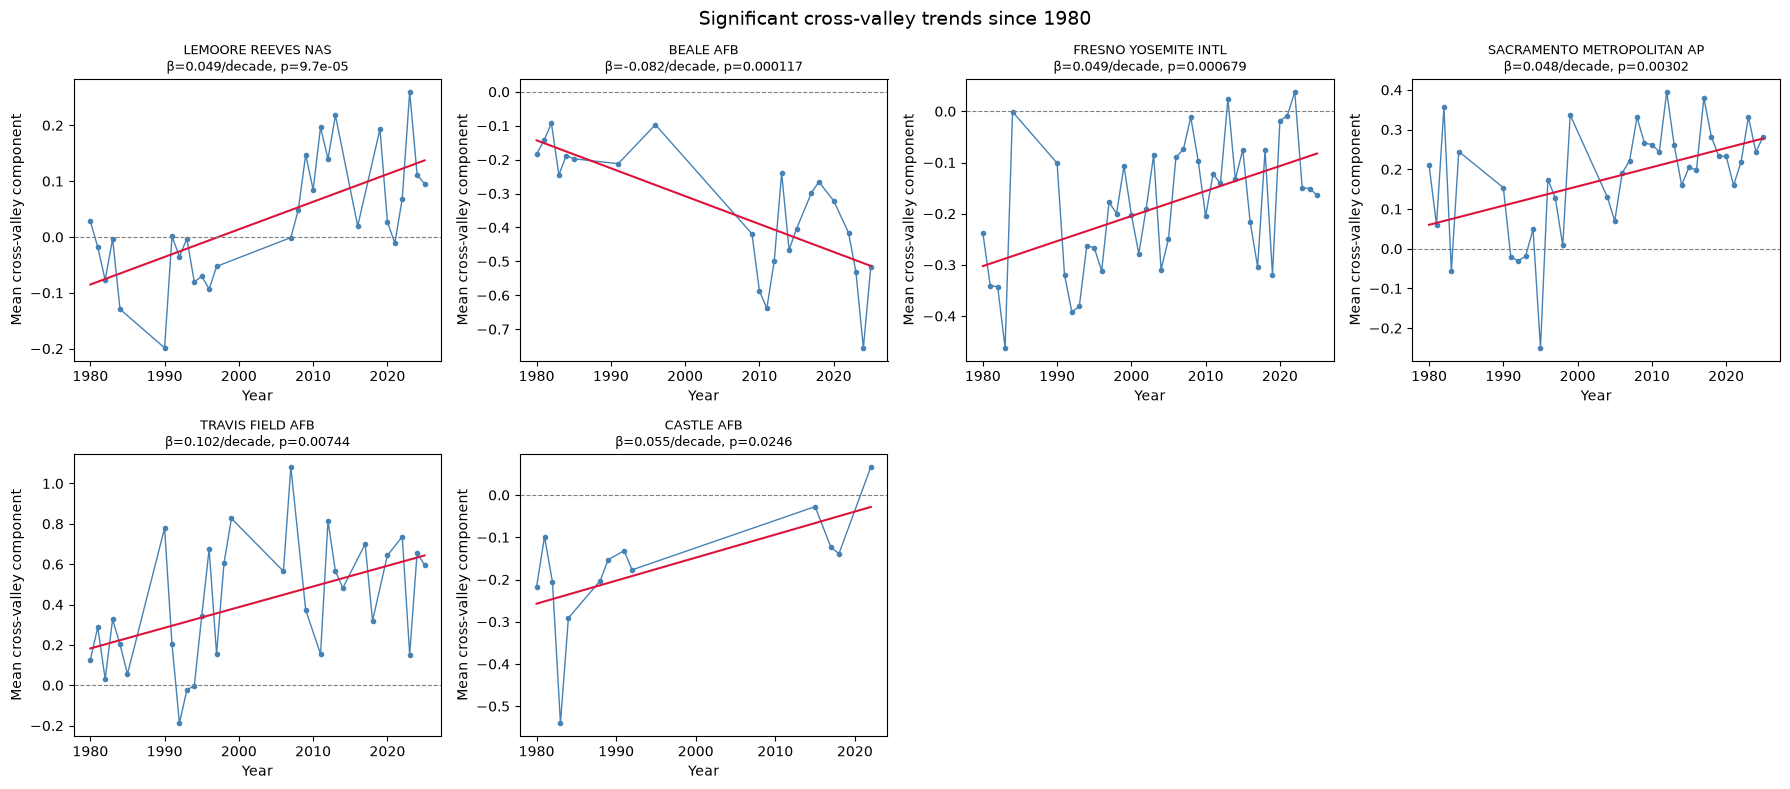

In [21]:
# Repeat the annual component analysis for station-years from 1980 onward

annual_components_1980 = (
    CV_filtered_rows.loc[CV_filtered_rows["year"] >= 1980]
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        mean_up_valley_component=("up_valley_component", "mean"),
        mean_cross_valley_component=("cross_valley_component", "mean"),
        n_obs=("up_valley_component", "count"),
    )
    .sort_values(["STATION", "year"])
)

trend_rows_1980 = []

for station, group in annual_components_1980.groupby("STATION"):
    for value_col, component_name in [
        ("mean_up_valley_component", "up_valley"),
        ("mean_cross_valley_component", "cross_valley"),
    ]:
        data = group[["year", value_col]].dropna()

        if data["year"].nunique() < 10 or data[value_col].nunique() < 2:
            continue

        fit = stats.linregress(data["year"], data[value_col])

        trend_rows_1980.append({
            "STATION": station,
            "component": component_name,
            "start_year": int(data["year"].min()),
            "end_year": int(data["year"].max()),
            "n_years": int(data["year"].nunique()),
            "slope_per_year": fit.slope,
            "slope_per_decade": fit.slope * 10,
            "intercept": fit.intercept,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

trend_df_1980 = pd.DataFrame(trend_rows_1980)
sig_trends_1980 = trend_df_1980[trend_df_1980["p_value"] < 0.05].copy()

display(annual_components_1980)
display(sig_trends_1980.sort_values(["component", "p_value"]))

# Plot significant trends
for component_name, value_col, ylabel in [
    ("up_valley", "mean_up_valley_component", "Mean up-valley component"),
    ("cross_valley", "mean_cross_valley_component", "Mean cross-valley component"),
]:
    significant = (
        sig_trends_1980[sig_trends_1980["component"] == component_name]
        .sort_values("p_value")
    )

    if significant.empty:
        print(f"No significant {component_name.replace('_', '-')} trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(significant) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(18, 4 * nrows), squeeze=False
    )
    axes = axes.ravel()

    for ax, (_, result) in zip(axes, significant.iterrows()):
        data = (
            annual_components_1980[
                annual_components_1980["STATION"] == result["STATION"]
            ][["year", value_col]]
            .dropna()
            .sort_values("year")
        )

        fitted = (
            result["intercept"]
            + result["slope_per_year"] * data["year"]
        )

        ax.plot(
            data["year"], data[value_col],
            marker="o", markersize=3, linewidth=1,
            color="steelblue"
        )
        ax.plot(data["year"], fitted, color="crimson", linewidth=1.5)
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

        ax.set_title(
            f"{result['STATION']}\n"
            f"β={result['slope_per_decade']:.3f}/decade, "
            f"p={result['p_value']:.3g}",
            fontsize=9,
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(ylabel)

    for ax in axes[len(significant):]:
        ax.remove()

    fig.suptitle(
        f"Significant {component_name.replace('_', '-')} trends since 1980",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

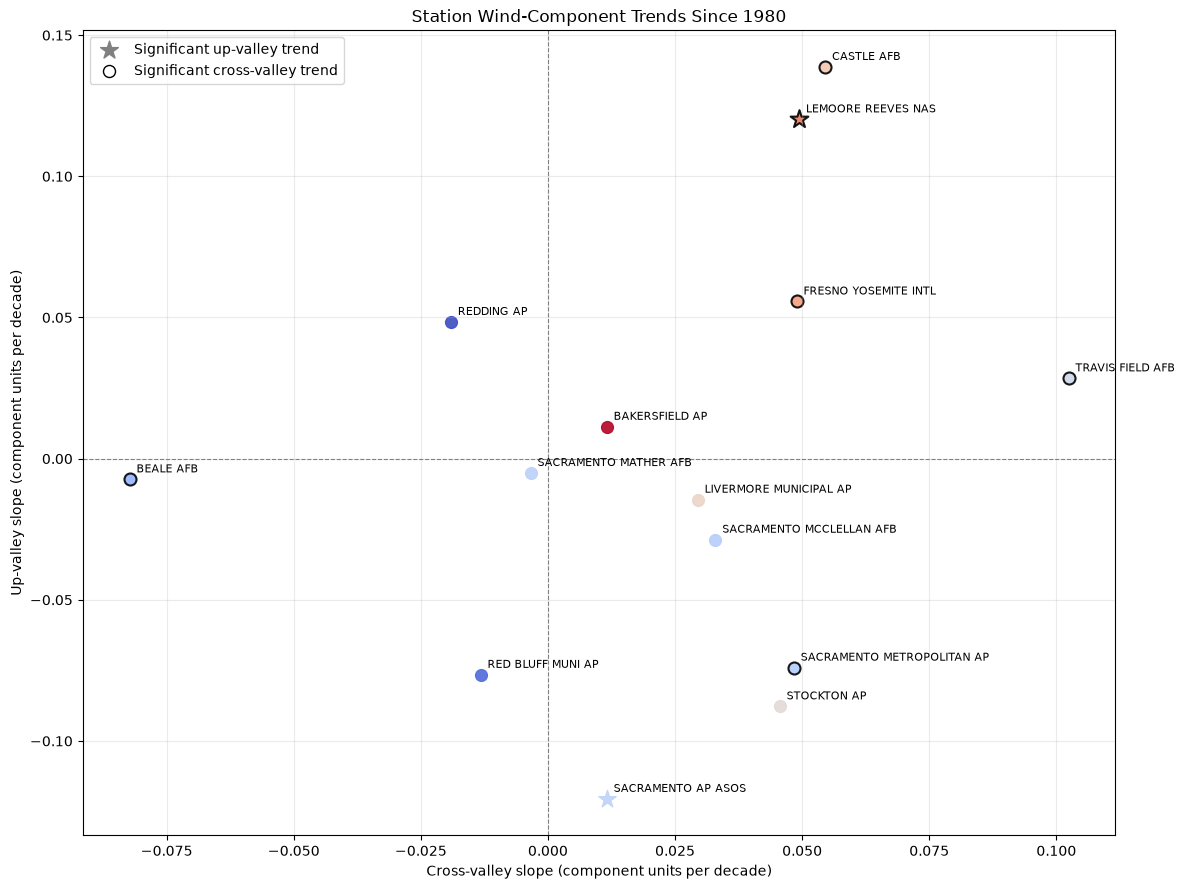

In [22]:
# Recreate the station trend plot with station names as point labels

slope_data_1980 = (
    trend_df_1980
    .pivot(index="STATION", columns="component", values=["slope_per_decade", "p_value"])
    .dropna()
)

# Flatten the multi-index columns for easier access, meaning
# each column will be named as "metric_component"
slope_data_1980.columns = [
    f"{metric}_{component}"
    for metric, component in slope_data_1980.columns
]

# Attach latitude for coloring
station_lat = (
    CV_filtered_rows.groupby("STATION", as_index=False)["LATITUDE"]
    .median()
    .rename(columns={"LATITUDE": "latitude"})
)

plot_data = slope_data_1980.merge(station_lat, on="STATION", how="left").dropna(subset=["latitude"])

lat_min = plot_data["latitude"].min()
lat_max = plot_data["latitude"].max()
lat_range = lat_max - lat_min if lat_max != lat_min else 1

fig, ax = plt.subplots(figsize=(12, 9))

for _, row in plot_data.iterrows():
    station = row["STATION"]
    color = plt.cm.coolwarm_r((row["latitude"] - lat_min) / lat_range)

    significant_cross = row["p_value_cross_valley"] < 0.05
    significant_up = row["p_value_up_valley"] < 0.05

    ax.scatter(
        row["slope_per_decade_cross_valley"],
        row["slope_per_decade_up_valley"],
        color=color,
        marker="*" if significant_up else "o",
        s=180 if significant_up else 75,
        edgecolors="black" if significant_cross else color,
        linewidths=1.5 if significant_cross else 0.8,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (
            row["slope_per_decade_cross_valley"],
            row["slope_per_decade_up_valley"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

ax.scatter([], [], color="gray", marker="*", s=180,
           label="Significant up-valley trend")
ax.scatter([], [], color="white", edgecolors="black", s=75,
           label="Significant cross-valley trend")

ax.set_xlabel("Cross-valley slope (component units per decade)")
ax.set_ylabel("Up-valley slope (component units per decade)")
ax.set_title("Station Wind-Component Trends Since 1980")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

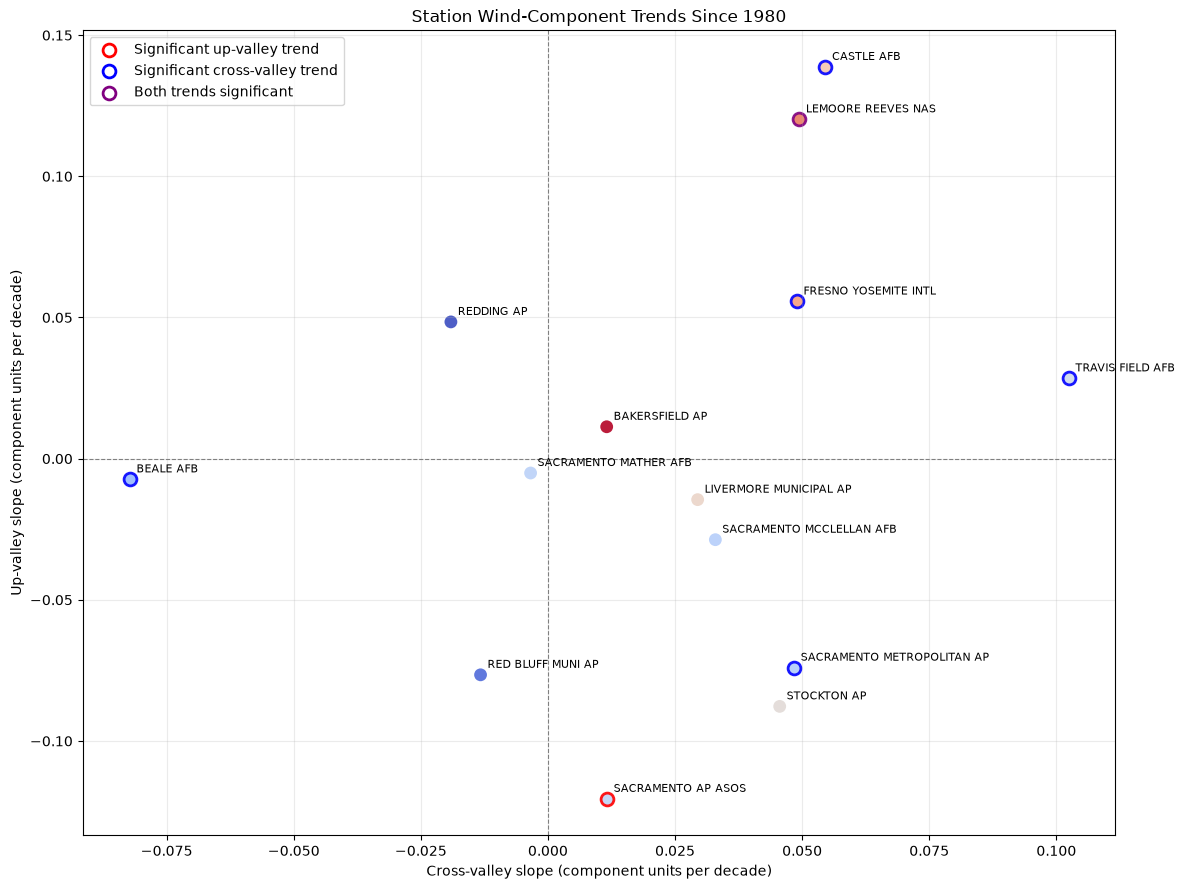

In [23]:
# Plot 1980 onward station trends with significance shown by outline color:
# red = significant up-valley trend
# blue = significant cross-valley trend
# purple = both significant

fig, ax = plt.subplots(figsize=(12, 9))

for _, row in plot_data.iterrows():
    station = row["STATION"]
    color = plt.cm.coolwarm_r((row["latitude"] - lat_min) / lat_range)

    significant_up = row["p_value_up_valley"] < 0.05
    significant_cross = row["p_value_cross_valley"] < 0.05

    if significant_up and significant_cross:
        outline_color = "purple"
    elif significant_up:
        outline_color = "red"
    elif significant_cross:
        outline_color = "blue"
    else:
        outline_color = "none"

    ax.scatter(
        row["slope_per_decade_cross_valley"],
        row["slope_per_decade_up_valley"],
        color=color,
        marker="o",
        s=85,
        edgecolors=outline_color,
        linewidths=2 if outline_color != "none" else 0.8,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (
            row["slope_per_decade_cross_valley"],
            row["slope_per_decade_up_valley"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

# Significance legend
for color, label in [
    ("red", "Significant up-valley trend"),
    ("blue", "Significant cross-valley trend"),
    ("purple", "Both trends significant"),
]:
    ax.scatter(
        [], [], color="white", edgecolors=color, marker="o",
        s=85, linewidths=2, label=label
    )

ax.set_xlabel("Cross-valley slope (component units per decade)")
ax.set_ylabel("Up-valley slope (component units per decade)")
ax.set_title("Station Wind-Component Trends Since 1980")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

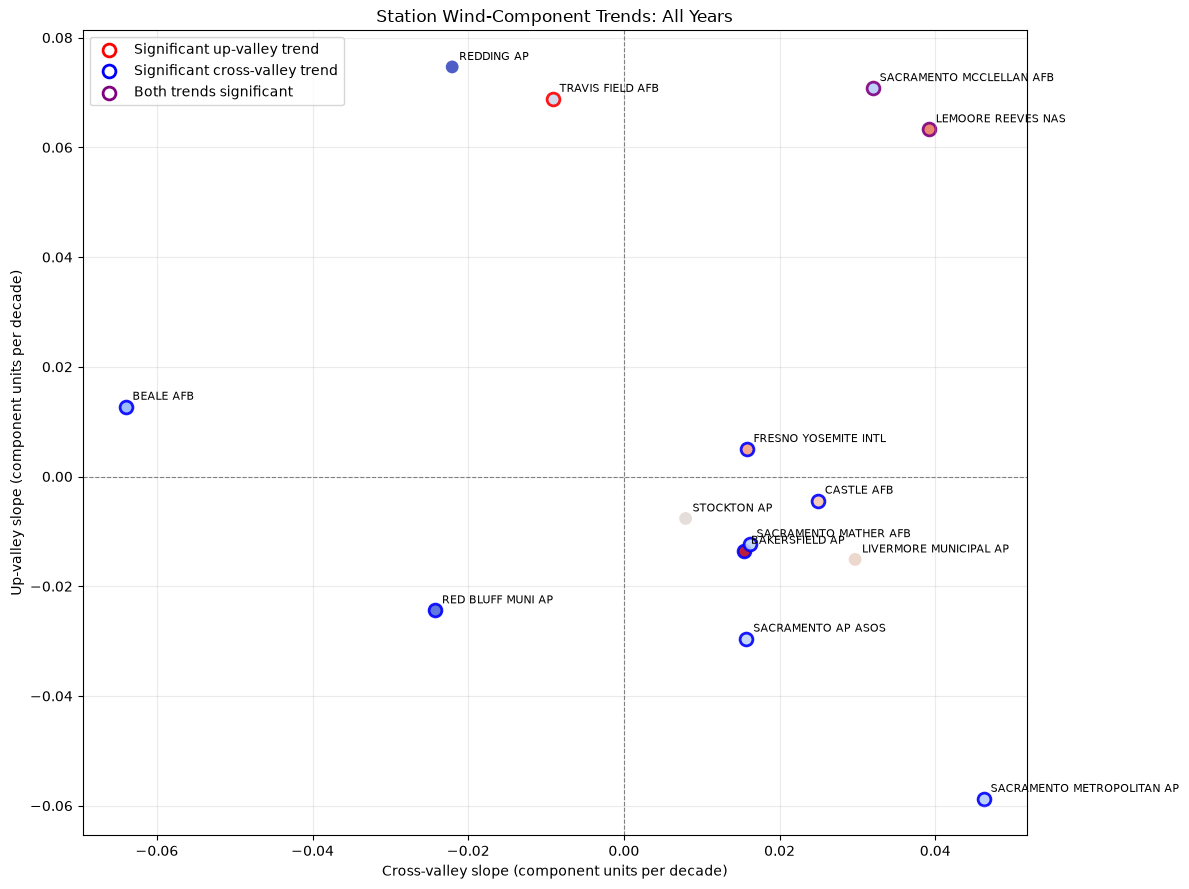

In [24]:
# Plot all-years station wind-component trends.
# Red outline = significant up-valley trend
# Blue outline = significant cross-valley trend
# Purple outline = both trends significant

slope_data_all = (
    trend_df
    .pivot(index="STATION", columns="component", values=["slope_per_decade", "p_value"])
    .dropna()
)

slope_data_all.columns = [
    f"{metric}_{component}"
    for metric, component in slope_data_all.columns
]

plot_data_all = (
    slope_data_all
    .reset_index()
    .merge(station_lat, on="STATION", how="left")
    .dropna(subset=["latitude"])
)

lat_min = plot_data_all["latitude"].min()
lat_max = plot_data_all["latitude"].max()
lat_range = lat_max - lat_min if lat_max != lat_min else 1

fig, ax = plt.subplots(figsize=(12, 9))

for _, row in plot_data_all.iterrows():
    significant_up = row["p_value_up_valley"] < 0.05
    significant_cross = row["p_value_cross_valley"] < 0.05

    if significant_up and significant_cross:
        outline_color = "purple"
    elif significant_up:
        outline_color = "red"
    elif significant_cross:
        outline_color = "blue"
    else:
        outline_color = "none"

    point_color = plt.cm.coolwarm_r(
        (row["latitude"] - lat_min) / lat_range
    )

    ax.scatter(
        row["slope_per_decade_cross_valley"],
        row["slope_per_decade_up_valley"],
        color=point_color,
        edgecolors=outline_color,
        linewidths=2 if outline_color != "none" else 0.8,
        s=85,
        alpha=0.9,
    )

    ax.annotate(
        row["STATION"],
        (
            row["slope_per_decade_cross_valley"],
            row["slope_per_decade_up_valley"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

for color, label in [
    ("red", "Significant up-valley trend"),
    ("blue", "Significant cross-valley trend"),
    ("purple", "Both trends significant"),
]:
    ax.scatter(
        [], [], color="white", edgecolors=color,
        marker="o", s=85, linewidths=2, label=label
    )

ax.set_xlabel("Cross-valley slope (component units per decade)")
ax.set_ylabel("Up-valley slope (component units per decade)")
ax.set_title("Station Wind-Component Trends: All Years")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

In [25]:
# Identify individual fog events as consecutive hourly fog observations (HourlyVisibility < 1)
fog_rows = CV_filtered_rows[CV_filtered_rows["HourlyVisibility"] < 1].copy()

# Construct timestamps from year, month, day, and hour
fog_rows["timestamp"] = (
    pd.to_datetime(fog_rows[["year", "month", "day"]])
    + pd.to_timedelta(fog_rows["hour"], unit="h")
)

fog_rows = fog_rows.dropna(subset=["timestamp"]).sort_values(["STATION", "timestamp"])

# Consecutive hourly observations belong to the same event
time_gap = fog_rows.groupby("STATION")["timestamp"].diff()
fog_rows["new_event"] = time_gap.isna() | (time_gap > pd.Timedelta(hours=1))
fog_rows["event_number"] = fog_rows.groupby("STATION")["new_event"].cumsum().astype(int)

# Aggregate events and calculate mean wind-direction components
fog_events = (
    fog_rows
    .groupby(["STATION", "event_number"], as_index=False)
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        n_observations=("timestamp", "size"),
        min_visibility=("HourlyVisibility", "min"),
        mean_visibility=("HourlyVisibility", "mean"),
        mean_up_valley_component=("up_valley_component", "mean"),
        mean_cross_valley_component=("cross_valley_component", "mean"),
        up_valley_direction=("up_valley_direction", "first"),
        cross_valley_direction=("cross_valley_direction", "first"),
    )
)

# Calculate duration in hours
fog_events["duration_hours"] = (
    (fog_events["end_time"] - fog_events["start_time"]).dt.total_seconds() / 3600 + 1
)

# Calculate average wind direction from mean components for each event
fog_events["avg_wind_direction_deg"] = np.mod(
    np.rad2deg(
        np.arctan2(
            fog_events["mean_cross_valley_component"],
            fog_events["mean_up_valley_component"]
        )
    ) + fog_events["up_valley_direction"],
    360.0
)

fog_events = fog_events.sort_values(["STATION", "start_time"]).reset_index(drop=True)

print(f"Total fog events: {len(fog_events)}")
display(fog_events.head(10))

Total fog events: 28270


,STATION,event_number,start_time,end_time,n_observations,min_visibility,mean_visibility,mean_up_valley_component,mean_cross_valley_component,up_valley_direction,cross_valley_direction,duration_hours,avg_wind_direction_deg
0,BAKERSFIELD AP,1,1932-01-01 07:00:00,1932-01-01 08:00:00,2,0.0,0.000000,-0.845649,0.764773,145.0,55.0,2.0,282.874984
1,BAKERSFIELD AP,2,1932-01-04 08:00:00,1932-01-04 08:00:00,1,0.0,0.000000,-2.265058,-0.399391,145.0,55.0,1.0,335.000000
2,BAKERSFIELD AP,3,1932-01-08 17:00:00,1932-01-08 18:00:00,2,0.0,0.000000,1.575692,0.277837,145.0,55.0,2.0,155.000000
3,BAKERSFIELD AP,4,1932-01-09 03:00:00,1932-01-09 08:00:00,6,0.0,0.366667,-0.618547,-0.513536,145.0,55.0,6.0,4.700459
4,BAKERSFIELD AP,5,1932-01-09 18:00:00,1932-01-09 18:00:00,1,0.0,0.000000,3.151385,0.555674,145.0,55.0,1.0,155.000000
5,BAKERSFIELD AP,6,1932-01-09 20:00:00,1932-01-10 07:00:00,12,0.0,0.283333,1.232621,1.472711,145.0,55.0,12.0,195.071541
6,BAKERSFIELD AP,7,1932-01-19 02:00:00,1932-01-19 03:00:00,2,0.2,0.500000,-2.690376,-1.623210,145.0,55.0,2.0,356.104236
7,BAKERSFIELD AP,8,1932-01-20 08:00:00,1932-01-20 08:00:00,1,0.8,0.800000,-2.265058,-0.399391,145.0,55.0,1.0,335.000000
8,BAKERSFIELD AP,9,1932-01-23 07:00:00,1932-01-23 08:00:00,2,0.0,0.000000,-0.516219,-0.737237,145.0,55.0,2.0,20.000000
9,BAKERSFIELD AP,10,1932-01-27 08:00:00,1932-01-27 08:00:00,1,0.2,0.200000,1.378731,0.243107,145.0,55.0,1.0,155.000000


,STATION,component,start_year,end_year,n_years,slope_per_year,slope_per_decade,r_squared,p_value,significant
7,FRESNO YOSEMITE INTL,cross_valley,1942,2025,71,-0.016208,-0.162079,0.125933,2.392529e-03,True
9,LEMOORE REEVES NAS,cross_valley,1962,2025,42,0.015456,0.154563,0.128253,1.987530e-02,True
27,TRAVIS FIELD AFB,cross_valley,1944,2025,60,0.011782,0.117821,0.057965,6.387696e-02,False
3,BEALE AFB,cross_valley,1960,2025,36,0.009858,0.098581,0.077344,1.005191e-01,False
13,RED BLUFF MUNI AP,cross_valley,1946,2024,68,-0.005154,-0.051538,0.036060,1.208929e-01,False
23,SACRAMENTO METROPOLITAN AP,cross_valley,1976,2025,39,0.009059,0.090592,0.057524,1.413874e-01,False
17,SACRAMENTO AP ASOS,cross_valley,1932,2025,82,0.003006,0.030056,0.021410,1.896144e-01,False
1,BAKERSFIELD AP,cross_valley,1932,2025,83,-0.005015,-0.050152,0.020073,2.013796e-01,False
21,SACRAMENTO MCCLELLAN AFB,cross_valley,1940,2025,58,0.002876,0.028759,0.013006,3.939874e-01,False
19,SACRAMENTO MATHER AFB,cross_valley,1942,2025,56,0.002387,0.023870,0.008108,5.092649e-01,False


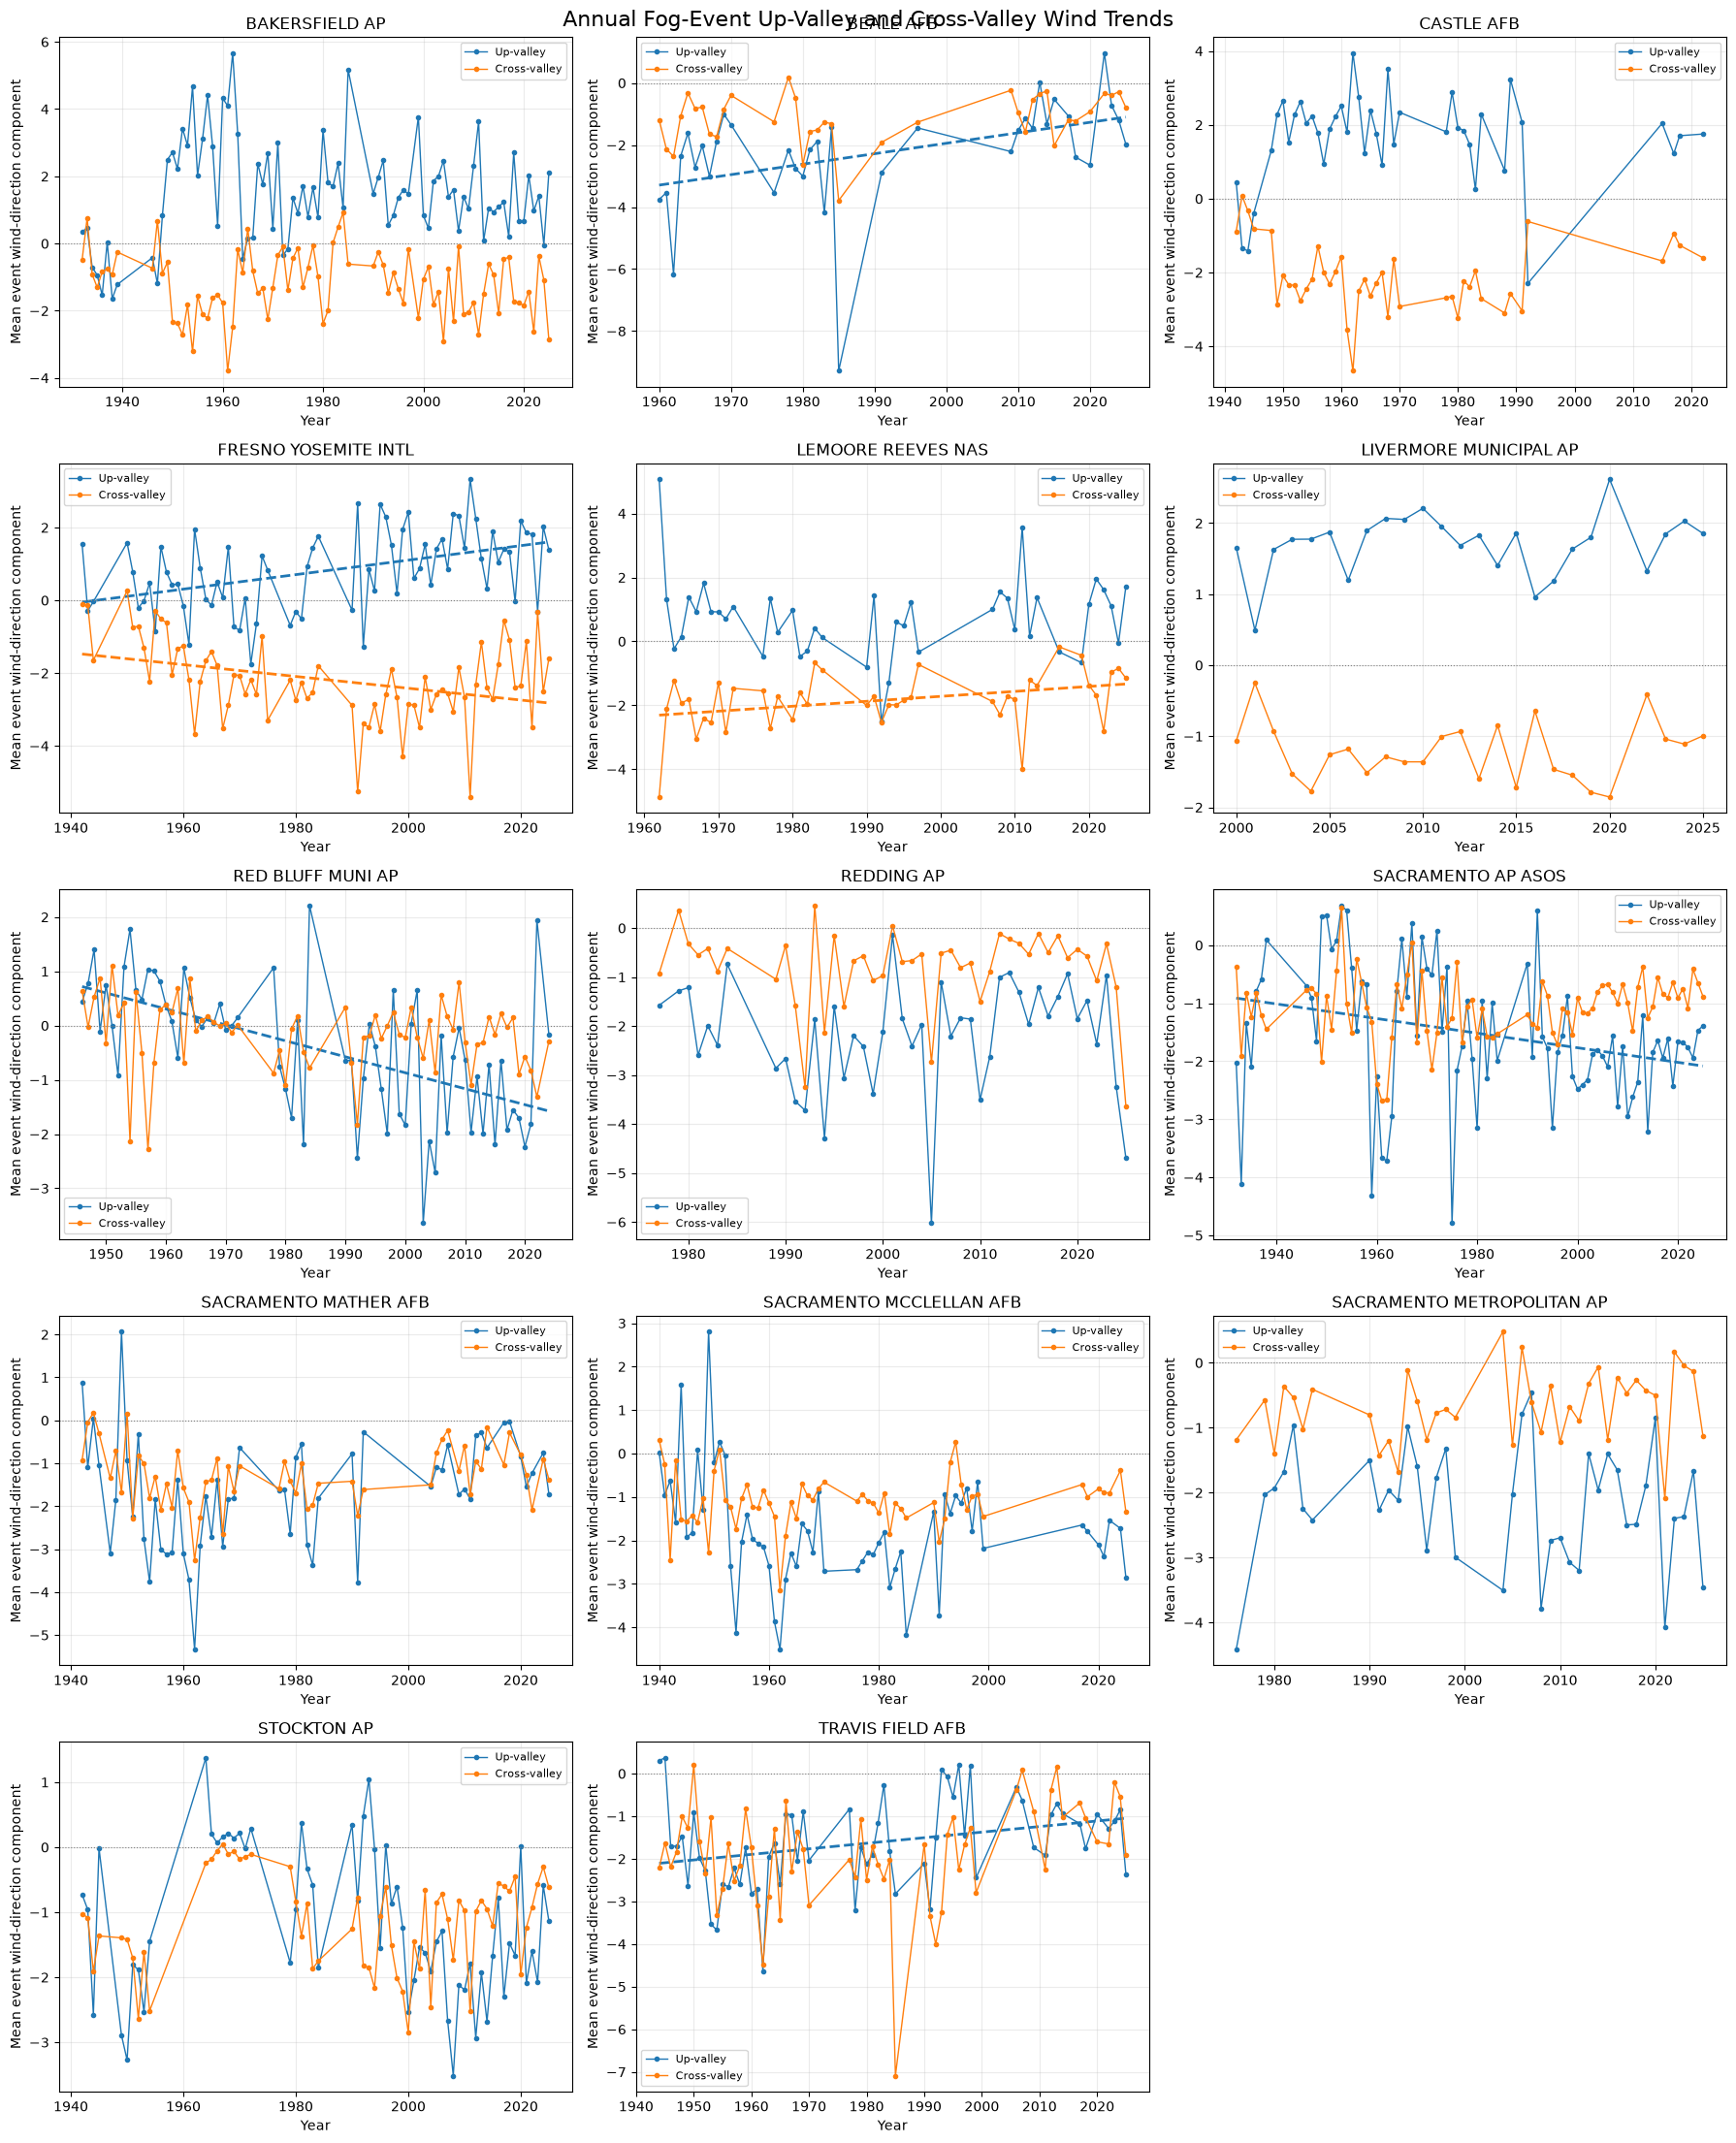

In [26]:
# Annual fog-event wind-direction trends by station.
# Regression lines are shown only when p < 0.05.

# Use the event observations created in cell 23
event_obs = fog_rows[
    [
        "STATION", "event_number", "year", "HourlyWindDirection",
        "up_valley_direction", "cross_valley_direction"
    ]
].copy()

event_obs["HourlyWindDirection"] = pd.to_numeric(
    event_obs["HourlyWindDirection"], errors="coerce"
)
event_obs = event_obs.dropna(subset=["HourlyWindDirection", "year"])

# Calculate circular mean wind direction for each fog event
event_obs["wind_rad"] = np.deg2rad(event_obs["HourlyWindDirection"])
event_obs["u"] = np.cos(event_obs["wind_rad"])
event_obs["v"] = np.sin(event_obs["wind_rad"])

event_wind = (
    event_obs
    .groupby(["STATION", "event_number"], as_index=False)
    .agg(
        year=("year", "first"),
        mean_u=("u", "mean"),
        mean_v=("v", "mean"),
        up_valley_direction=("up_valley_direction", "first"),
        cross_valley_direction=("cross_valley_direction", "first"),
        n_observations=("HourlyWindDirection", "size"),
    )
)

event_wind["event_mean_direction"] = np.mod(
    np.rad2deg(np.arctan2(event_wind["mean_v"], event_wind["mean_u"])),
    360
)

# Calculate event-level alignment with each local axis
# multiply by the wind speed for each event to get the actual wind component along the up-valley direction
event_wind["up_valley_component"] = np.cos(
    np.deg2rad(
        event_wind["event_mean_direction"]
        - event_wind["up_valley_direction"]
    )
) * event_wind["n_observations"]

event_wind["cross_valley_component"] = np.cos(
    np.deg2rad(
        event_wind["event_mean_direction"]
        - event_wind["cross_valley_direction"]
    )
) * event_wind["n_observations"]

# Annual averages of fog-event directional components
annual_event_wind = (
    event_wind
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        mean_up_valley_component=("up_valley_component", "mean"),
        mean_cross_valley_component=("cross_valley_component", "mean"),
        n_events=("event_number", "size"),
    )
    .sort_values(["STATION", "year"])
)

# Fit trends for each station and component
event_trend_rows = []

for station, group in annual_event_wind.groupby("STATION"):
    for component, column in [
        ("up_valley", "mean_up_valley_component"),
        ("cross_valley", "mean_cross_valley_component"),
    ]:
        data = group[["year", column]].dropna()

        if data["year"].nunique() < 3 or data[column].nunique() < 2:
            continue

        fit = stats.linregress(data["year"], data[column])

        event_trend_rows.append({
            "STATION": station,
            "component": component,
            "start_year": int(data["year"].min()),
            "end_year": int(data["year"].max()),
            "n_years": int(data["year"].nunique()),
            "slope_per_year": fit.slope,
            "slope_per_decade": fit.slope * 10,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

event_trends = pd.DataFrame(event_trend_rows)
event_trends["significant"] = event_trends["p_value"] < 0.05

display(event_trends.sort_values(["component", "p_value"]))

# Plot both components for every station
stations = sorted(annual_event_wind["STATION"].unique())
ncols = 3
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(18, 4.5 * nrows),
    squeeze=False
)
axes = axes.ravel()

for ax, station in zip(axes, stations):
    data = annual_event_wind[
        annual_event_wind["STATION"] == station
    ].sort_values("year")

    for component, column, color, label in [
        (
            "up_valley",
            "mean_up_valley_component",
            "tab:blue",
            "Up-valley",
        ),
        (
            "cross_valley",
            "mean_cross_valley_component",
            "tab:orange",
            "Cross-valley",
        ),
    ]:
        ax.plot(
            data["year"],
            data[column],
            marker="o",
            markersize=3,
            linewidth=1,
            color=color,
            label=label,
        )

        result = event_trends[
            (event_trends["STATION"] == station)
            & (event_trends["component"] == component)
        ]

        # Add a regression line only for significant trends
        if not result.empty and result.iloc[0]["significant"]:
            result = result.iloc[0]
            fitted = (
                result["slope_per_year"] * data["year"]
                + (
                    data[column].mean()
                    - result["slope_per_year"] * data["year"].mean()
                )
            )

            ax.plot(
                data["year"],
                fitted,
                color=color,
                linestyle="--",
                linewidth=2,
            )

    ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
    ax.set_title(station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean event wind-direction component")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

for ax in axes[len(stations):]:
    ax.remove()

fig.suptitle(
    "Annual Fog-Event Up-Valley and Cross-Valley Wind Trends",
    fontsize=16,
)
plt.tight_layout()
plt.show()

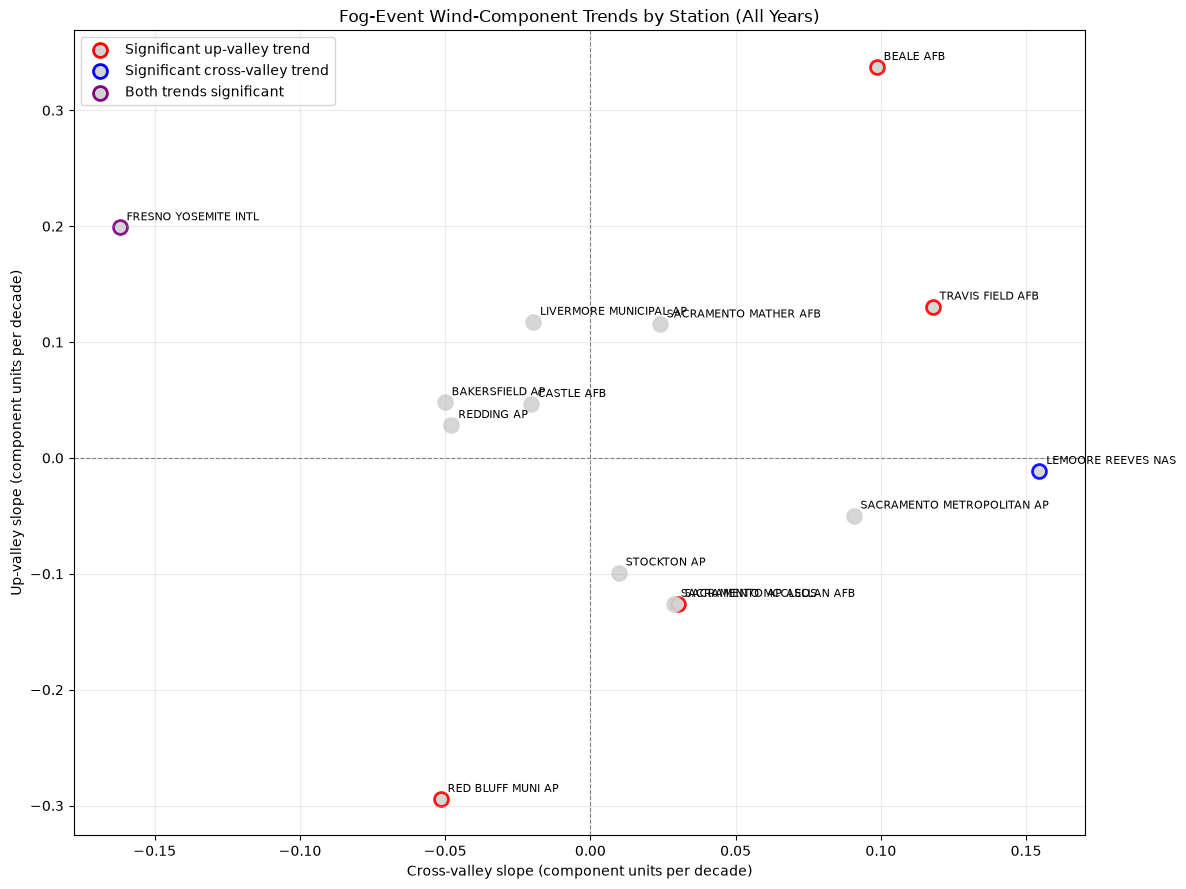

In [27]:
# Plot fog-event trend slopes:
# x-axis = cross-valley slope; y-axis = up-valley slope.
# Red outline = significant up-valley trend
# Blue outline = significant cross-valley trend
# Purple outline = both trends significant

fog_slope_data = (
    event_trends
    .pivot(index="STATION", columns="component",
           values=["slope_per_decade", "p_value"])
    .dropna()
)

fog_slope_data.columns = [
    f"{metric}_{component}"
    for metric, component in fog_slope_data.columns
]

fig, ax = plt.subplots(figsize=(12, 9))

for station, row in fog_slope_data.iterrows():
    significant_up = row["p_value_up_valley"] < 0.05
    significant_cross = row["p_value_cross_valley"] < 0.05

    if significant_up and significant_cross:
        outline_color = "purple"
    elif significant_up:
        outline_color = "red"
    elif significant_cross:
        outline_color = "blue"
    else:
        outline_color = "lightgray"

    ax.scatter(
        row["slope_per_decade_cross_valley"],
        row["slope_per_decade_up_valley"],
        s=100,
        facecolor="lightgray",
        edgecolor=outline_color,
        linewidth=2,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (
            row["slope_per_decade_cross_valley"],
            row["slope_per_decade_up_valley"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

for color, label in [
    ("red", "Significant up-valley trend"),
    ("blue", "Significant cross-valley trend"),
    ("purple", "Both trends significant"),
]:
    ax.scatter(
        [], [], s=100, facecolor="lightgray",
        edgecolor=color, linewidth=2, label=label
    )

ax.set_xlabel("Cross-valley slope (component units per decade)")
ax.set_ylabel("Up-valley slope (component units per decade)")
ax.set_title("Fog-Event Wind-Component Trends by Station (All Years)")
ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

,STATION,component,start_year,end_year,n_years,slope_per_year,slope_per_decade,r_squared,p_value,significant
17,SACRAMENTO AP ASOS,cross_valley,1980,2025,41,0.017469,0.174694,0.413077,0.000006,True
3,BEALE AFB,cross_valley,1980,2025,22,0.034058,0.340581,0.409916,0.001330,True
27,TRAVIS FIELD AFB,cross_valley,1980,2025,30,0.053221,0.532209,0.291717,0.002064,True
7,FRESNO YOSEMITE INTL,cross_valley,1980,2025,41,0.028843,0.288429,0.131988,0.019557,True
5,CASTLE AFB,cross_valley,1980,2022,13,0.033210,0.332103,0.401357,0.020086,True
25,STOCKTON AP,cross_valley,1980,2025,41,0.017335,0.173352,0.121275,0.025664,True
1,BAKERSFIELD AP,cross_valley,1980,2025,41,-0.024110,-0.241099,0.119091,0.027124,True
19,SACRAMENTO MATHER AFB,cross_valley,1980,2025,25,0.017473,0.174734,0.193657,0.027708,True
21,SACRAMENTO MCCLELLAN AFB,cross_valley,1980,2025,23,0.010171,0.101712,0.096601,0.148882,False
23,SACRAMENTO METROPOLITAN AP,cross_valley,1980,2025,37,0.009205,0.092052,0.050357,0.181795,False


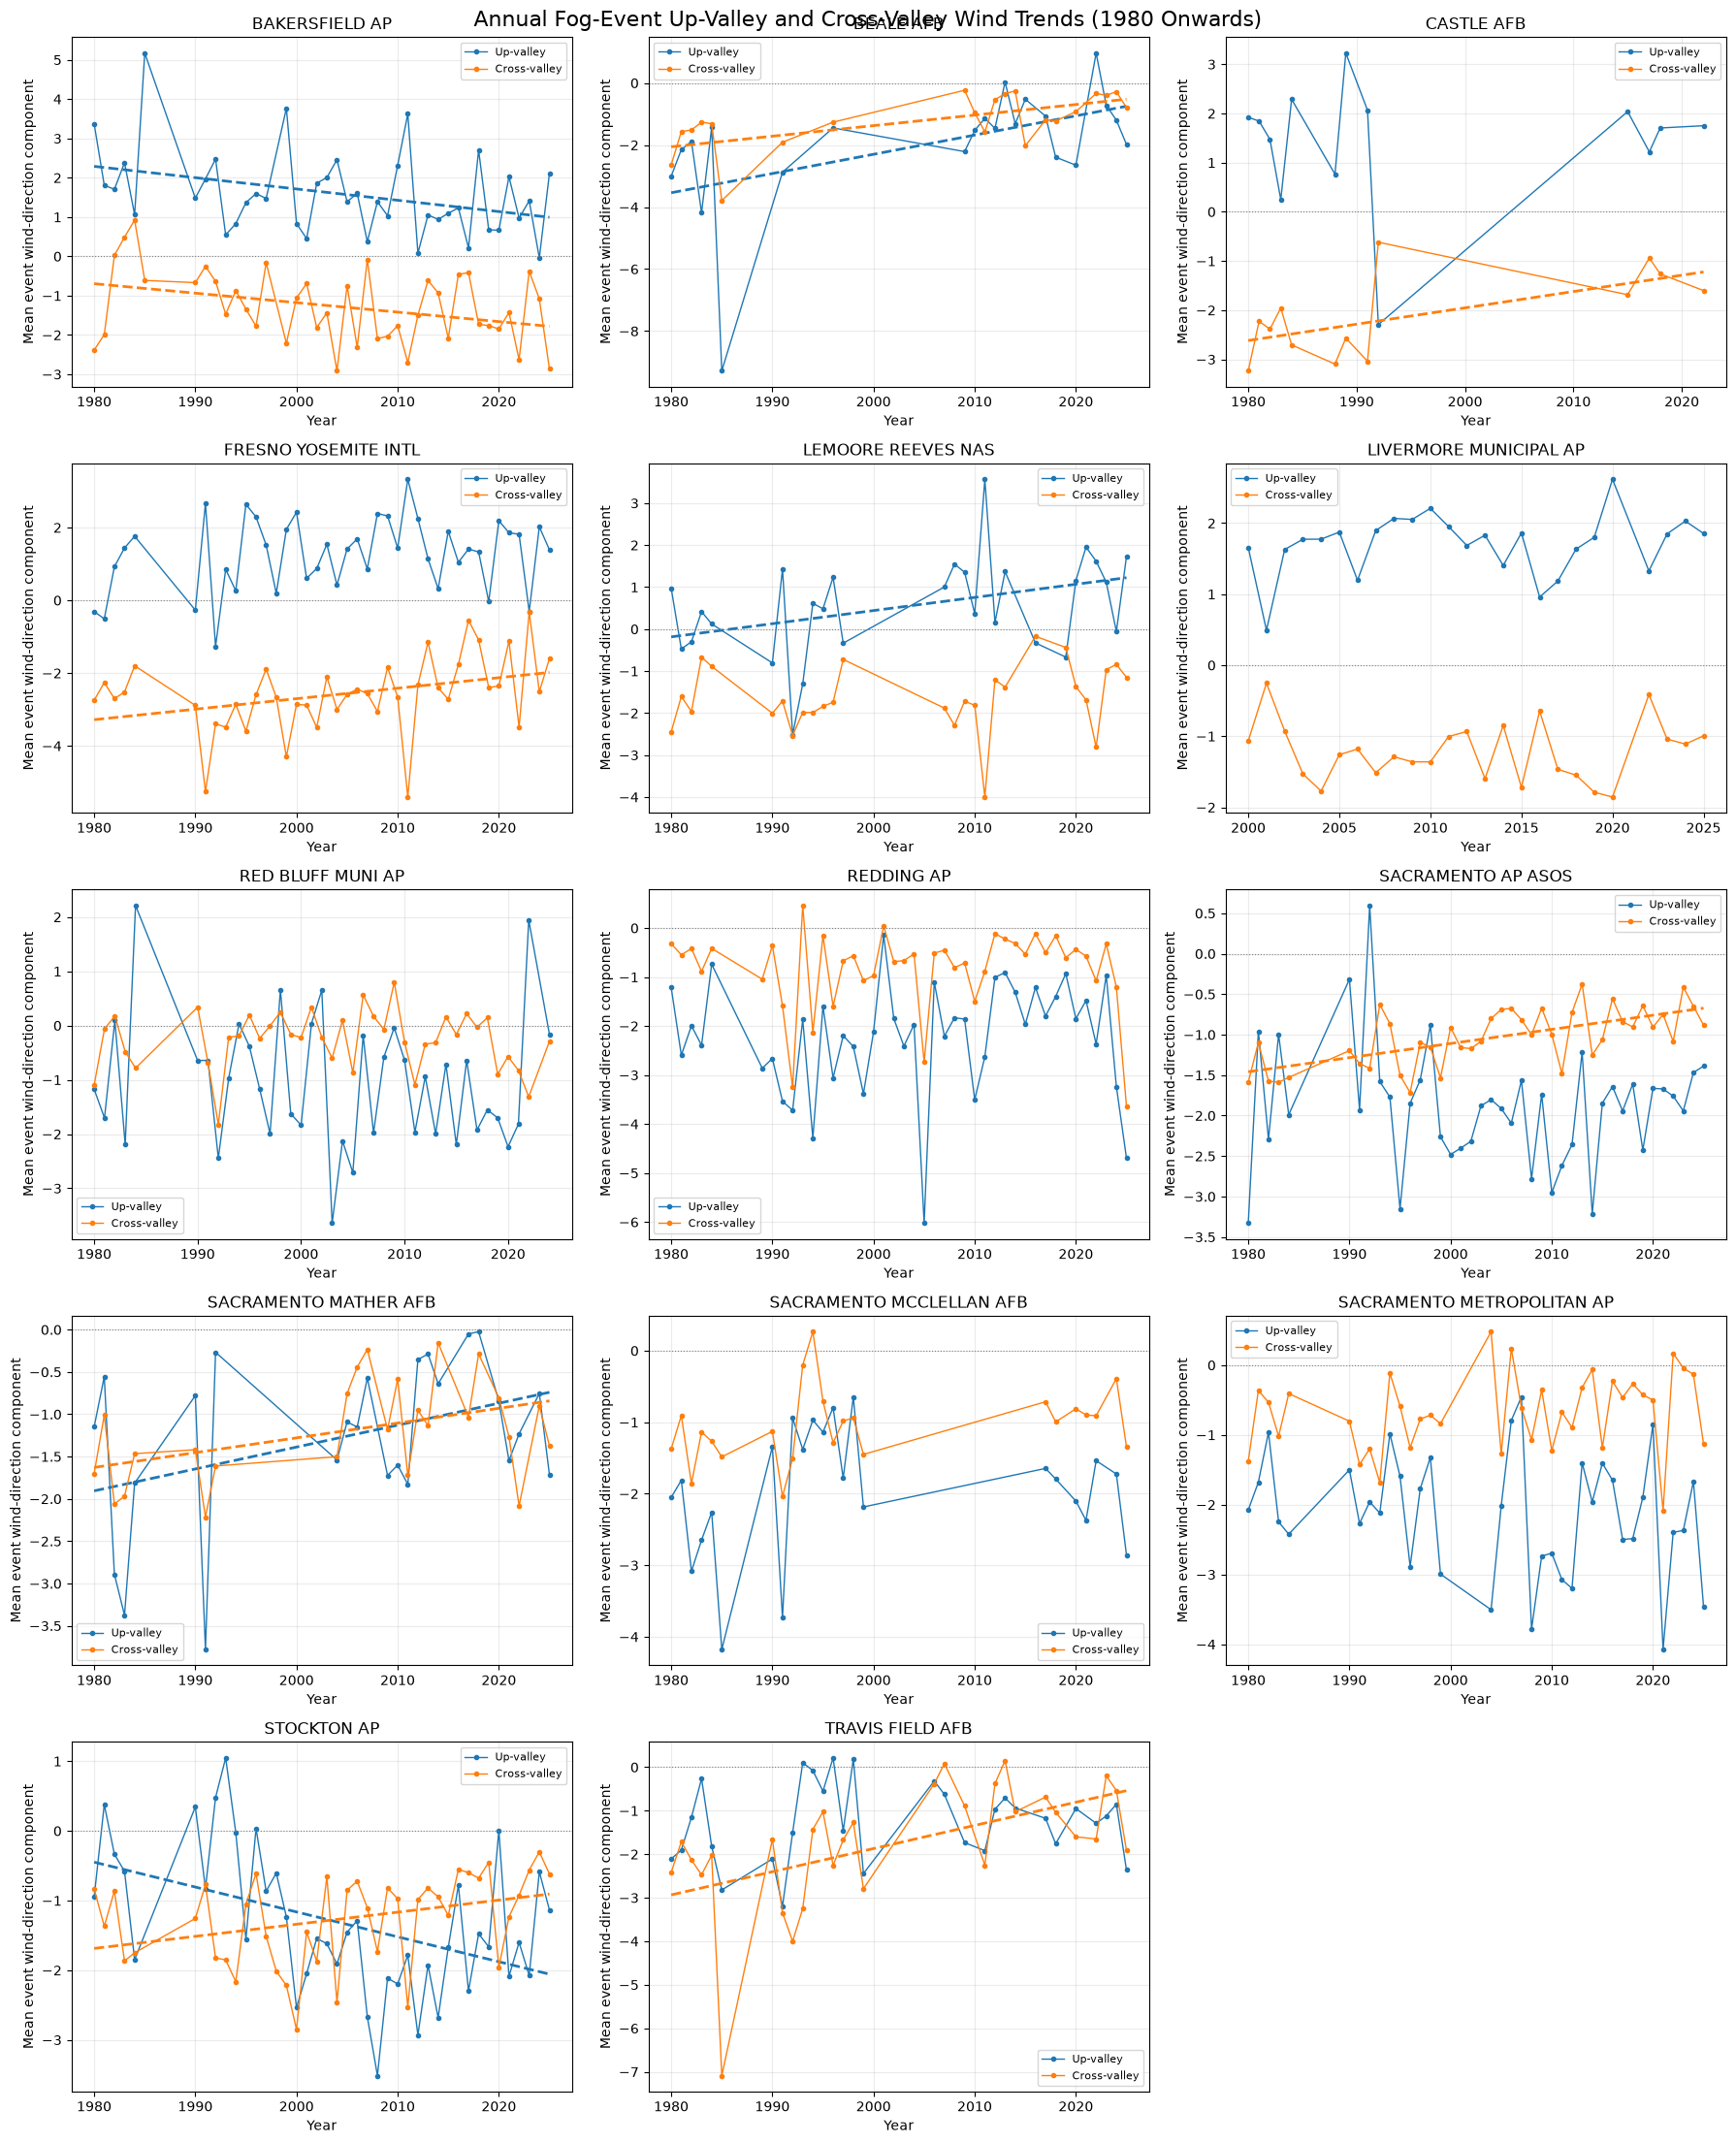

In [28]:
# Annual fog-event wind-direction trends by station.
# Only for years since 1980
# Regression lines are shown only when p < 0.05.

# Use the event observations created in cell 23
event_obs1980 = fog_rows[
    [
        "STATION", "event_number", "year", "HourlyWindDirection",
        "up_valley_direction", "cross_valley_direction"
    ]
].copy()

event_obs1980["HourlyWindDirection"] = pd.to_numeric(
    event_obs1980["HourlyWindDirection"], errors="coerce"
)
event_obs1980 = event_obs1980.dropna(subset=["HourlyWindDirection", "year"])
event_obs1980 = event_obs1980[event_obs1980["year"] >= 1980]

# Calculate circular mean wind direction for each fog event
event_obs1980["wind_rad"] = np.deg2rad(event_obs1980["HourlyWindDirection"])
event_obs1980["u"] = np.cos(event_obs1980["wind_rad"])
event_obs1980["v"] = np.sin(event_obs1980["wind_rad"])

event_wind1980 = (
    event_obs1980
    .groupby(["STATION", "event_number"], as_index=False)
    .agg(
        year=("year", "first"),
        mean_u=("u", "mean"),
        mean_v=("v", "mean"),
        up_valley_direction=("up_valley_direction", "first"),
        cross_valley_direction=("cross_valley_direction", "first"),
        n_observations=("HourlyWindDirection", "size"),
    )
)

event_wind1980["event_mean_direction"] = np.mod(
    np.rad2deg(np.arctan2(event_wind1980["mean_v"], event_wind1980["mean_u"])),
    360
)

# Calculate event-level alignment with each local axis
# multiply by the wind magnitude to get the actual wind component along the up-valley direction
event_wind1980["up_valley_component"] = np.cos(
    np.deg2rad(
        event_wind1980["event_mean_direction"]
        - event_wind1980["up_valley_direction"]
    )
) * event_wind1980["n_observations"]

event_wind1980["cross_valley_component"] = np.cos(
    np.deg2rad(
        event_wind1980["event_mean_direction"]
        - event_wind1980["cross_valley_direction"]
    )
) * event_wind1980["n_observations"]

# Annual averages of fog-event directional components
annual_event_wind1980 = (
    event_wind1980
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        mean_up_valley_component=("up_valley_component", "mean"),
        mean_cross_valley_component=("cross_valley_component", "mean"),
        n_events=("event_number", "size"),
    )
    .sort_values(["STATION", "year"])
)

# Fit trends for each station and component
event_trend_rows = []

for station, group in annual_event_wind1980.groupby("STATION"):
    for component, column in [
        ("up_valley", "mean_up_valley_component"),
        ("cross_valley", "mean_cross_valley_component"),
    ]:
        data = group[["year", column]].dropna()

        if data["year"].nunique() < 3 or data[column].nunique() < 2:
            continue

        fit = stats.linregress(data["year"], data[column])

        event_trend_rows.append({
            "STATION": station,
            "component": component,
            "start_year": int(data["year"].min()),
            "end_year": int(data["year"].max()),
            "n_years": int(data["year"].nunique()),
            "slope_per_year": fit.slope,
            "slope_per_decade": fit.slope * 10,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

event_trends1980 = pd.DataFrame(event_trend_rows)
event_trends1980["significant"] = event_trends1980["p_value"] < 0.05

display(event_trends1980.sort_values(["component", "p_value"]))

# Plot both components for every station
stations = sorted(annual_event_wind1980["STATION"].unique())
ncols = 3
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(18, 4.5 * nrows),
    squeeze=False
)
axes = axes.ravel()

for ax, station in zip(axes, stations):
    data = annual_event_wind1980[
        annual_event_wind1980["STATION"] == station
    ].sort_values("year")

    for component, column, color, label in [
        (
            "up_valley",
            "mean_up_valley_component",
            "tab:blue",
            "Up-valley",
        ),
        (
            "cross_valley",
            "mean_cross_valley_component",
            "tab:orange",
            "Cross-valley",
        ),
    ]:
        ax.plot(
            data["year"],
            data[column],
            marker="o",
            markersize=3,
            linewidth=1,
            color=color,
            label=label,
        )

        result = event_trends1980[
            (event_trends1980["STATION"] == station)
            & (event_trends1980["component"] == component)
        ]

        # Add a regression line only for significant trends
        if not result.empty and result.iloc[0]["significant"]:
            result = result.iloc[0]
            fitted = (
                result["slope_per_year"] * data["year"]
                + (
                    data[column].mean()
                    - result["slope_per_year"] * data["year"].mean()
                )
            )

            ax.plot(
                data["year"],
                fitted,
                color=color,
                linestyle="--",
                linewidth=2,
            )

    ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
    ax.set_title(station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean event wind-direction component")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

for ax in axes[len(stations):]:
    ax.remove()

fig.suptitle(
    "Annual Fog-Event Up-Valley and Cross-Valley Wind Trends (1980 Onwards)",
    fontsize=16,
)
plt.tight_layout()
plt.show()

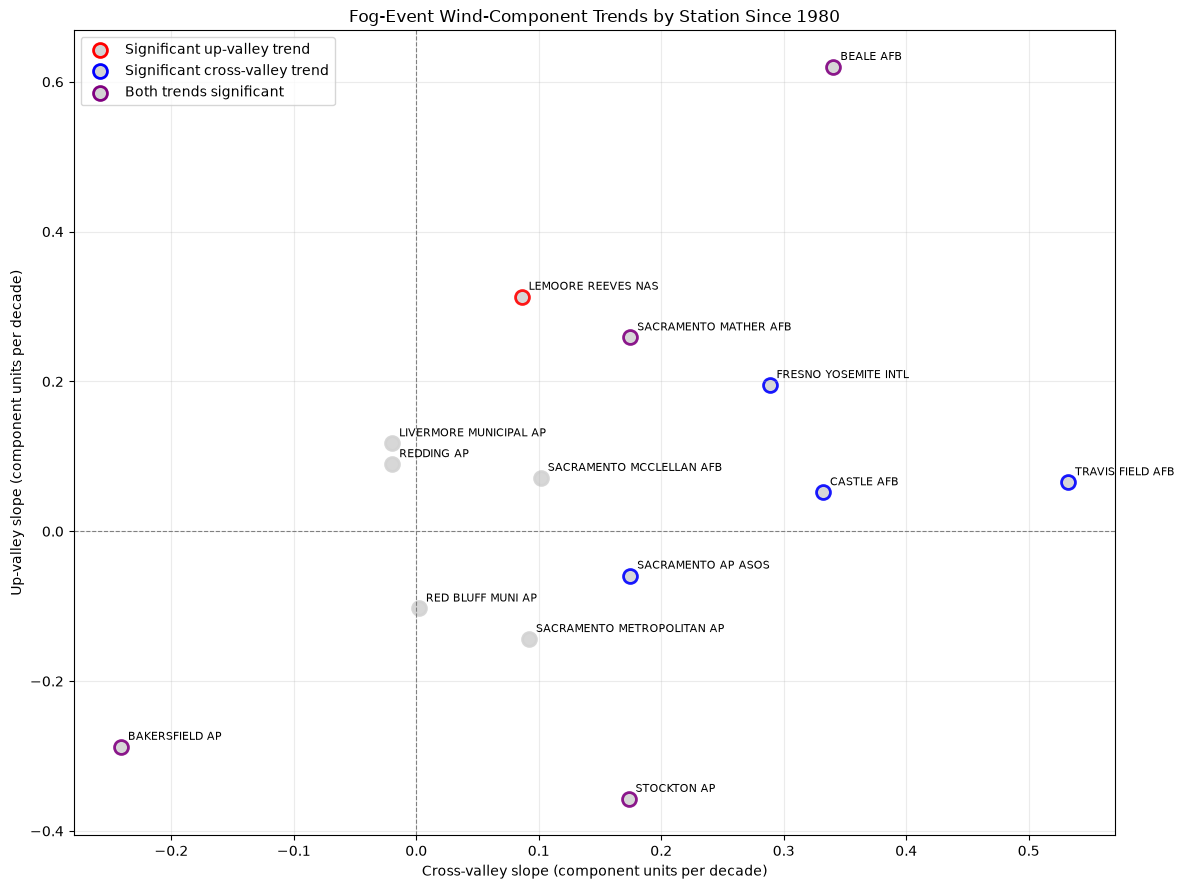

In [29]:
# Plot fog-event trend slopes since 1980
# x-axis = cross-valley slope; y-axis = up-valley slope.
# Red outline = significant up-valley trend
# Blue outline = significant cross-valley trend
# Purple outline = both trends significant

fog_slope_data1980 = (
    event_trends1980
    .pivot(index="STATION", columns="component",
           values=["slope_per_decade", "p_value"])
    .dropna()
)

fog_slope_data1980.columns = [
    f"{metric}_{component}"
    for metric, component in fog_slope_data1980.columns
]

fig, ax = plt.subplots(figsize=(12, 9))

for station, row in fog_slope_data1980.iterrows():
    significant_up1980 = row["p_value_up_valley"] < 0.05
    significant_cross1980 = row["p_value_cross_valley"] < 0.05

    if significant_up1980 and significant_cross1980:
        outline_color = "purple"
    elif significant_up1980:
        outline_color = "red"
    elif significant_cross1980:
        outline_color = "blue"
    else:
        outline_color = "lightgray"

    ax.scatter(
        row["slope_per_decade_cross_valley"],
        row["slope_per_decade_up_valley"],
        s=100,
        facecolor="lightgray",
        edgecolor=outline_color,
        linewidth=2,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (
            row["slope_per_decade_cross_valley"],
            row["slope_per_decade_up_valley"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

for color, label in [
    ("red", "Significant up-valley trend"),
    ("blue", "Significant cross-valley trend"),
    ("purple", "Both trends significant"),
]:
    ax.scatter(
        [], [], s=100, facecolor="lightgray",
        edgecolor=color, linewidth=2, label=label
    )

ax.set_xlabel("Cross-valley slope (component units per decade)")
ax.set_ylabel("Up-valley slope (component units per decade)")
ax.set_title("Fog-Event Wind-Component Trends by Station Since 1980")
ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()